# HealthPark Emergency Department: Fault Tree → Bayesian Network → Dynamic Bayesian Network

### Fault tree model used here

Basic events are binary (`0 = functional/no failure`, `1 = failed/damaged`):

- `X1`: power plant failure
- `X2`: substation failure (single simplified substation; no grid redundancy)
- `X3`: emergency generator failure (no runtime/activation clock)
- `X4`: water treatment plant failure
- `X5`: Lee Fiber failure
- `X6`: Lumen failure
- `X7`: Comcast failure (single simplified Comcast service)
- `X8`: physical damage to the ED caused by flooding

Deterministic fault-tree logic:

- `M1 = X1 OR X2` — external grid supply unavailable
- `M2 = X3` — emergency power unavailable
- `E = M1 AND M2` — essential electrical service unavailable
- `M3 = X4` and `W = M3` — required water supply unavailable
- `M4 = X5 AND X6 AND X7` and `C = M4` — required communication unavailable

The top ED node is **not** a deterministic OR gate. It is a three-state Bayesian node:

- `0 = Full`
- `1 = Partial`
- `2 = Nonfunctional`

with

$$
P(F_{ED}\mid E,W,C,X8).
$$


For the DBN, temporal persistence/recovery is applied to `X1`–`X8`. Intermediate FT nodes (`M1`–`M4`, `E`, `W`, `C`) are recomputed deterministically in each time slice. The ED state has no self-transition in this first version; persistence is represented through its physical/service parents. A later model can add `ED(t-1) → ED(t)` if operational hysteresis needs to be represented explicitly.

## 1. Imports and conventions

The notebook uses only NumPy, pandas, matplotlib, and NetworkX. `pgmpy` is not required: the BN structure and CPTs are represented explicitly, and the DBN is simulated with Monte Carlo state transitions.

In [32]:
import math
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

FT_TO_M = 0.3048

# Binary event convention used throughout the FT/BN/DBN.
FUNCTIONAL = 0
FAILED = 1

ED_STATE_LABELS = {
    0: "Full",
    1: "Partial",
    2: "Nonfunctional",
}

## 2. Fault-tree and BN node definitions

The intermediate nodes are retained rather than collapsed so that the Python structure matches the fault-tree diagram and can be cross-referenced in the manuscript.

In [33]:
BASIC_EVENTS = {
    "X1": "Power plant failure",
    "X2": "Substation failure",
    "X3": "Emergency generator failure",
    "X4": "Water treatment plant failure",
    "X5": "Lee Fiber failure",
    "X6": "Lumen failure",
    "X7": "Comcast failure",
    "X8": "ED physical damage caused by flooding",
}

FT_MODEL = {
    "M1": {
        "name": "External grid supply unavailable",
        "gate": "OR",
        "parents": ["X1", "X2"],
    },
    "M2": {
        "name": "Emergency power unavailable",
        "gate": "IDENTITY",
        "parents": ["X3"],
    },
    "E": {
        "name": "Essential electrical service unavailable",
        "gate": "AND",
        "parents": ["M1", "M2"],
    },
    "M3": {
        "name": "External water supply unavailable",
        "gate": "IDENTITY",
        "parents": ["X4"],
    },
    "W": {
        "name": "Required water supply unavailable",
        "gate": "IDENTITY",
        "parents": ["M3"],
    },
    "M4": {
        "name": "External communication service unavailable",
        "gate": "AND",
        "parents": ["X5", "X6", "X7"],
    },
    "C": {
        "name": "Required communication unavailable",
        "gate": "IDENTITY",
        "parents": ["M4"],
    },
}

ED_PARENTS = ["E", "W", "C", "X8"]
ED_NODE = "ED_functionality"

# Static BN edges: deterministic FT portion + probabilistic ED functionality node.
BN_EDGES = []
for child, spec in FT_MODEL.items():
    BN_EDGES.extend((parent, child) for parent in spec["parents"])
BN_EDGES.extend((parent, ED_NODE) for parent in ED_PARENTS)

bn_structure = nx.DiGraph(BN_EDGES)

if not nx.is_directed_acyclic_graph(bn_structure):
    raise ValueError("The within-slice Bayesian network must be acyclic.")

print("Basic events:", list(BASIC_EVENTS))
print("Within-slice BN nodes:", list(nx.topological_sort(bn_structure)))

Basic events: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
Within-slice BN nodes: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'M1', 'M2', 'M3', 'M4', 'E', 'W', 'C', 'ED_functionality']


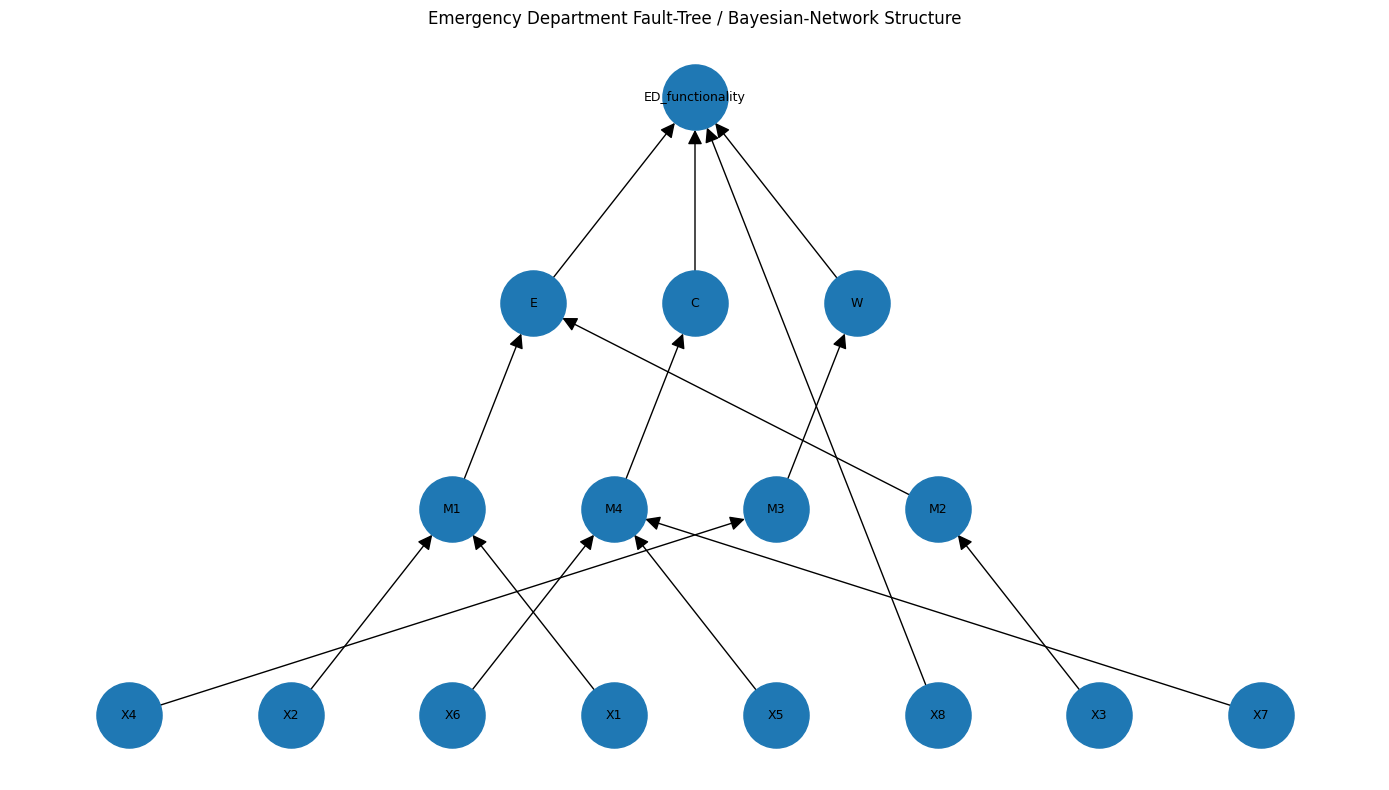

In [34]:
# Optional structural visualization.
layer_map = {
    **{node: 0 for node in BASIC_EVENTS},
    "M1": 1, "M2": 1, "M3": 1, "M4": 1,
    "E": 2, "W": 2, "C": 2,
    ED_NODE: 3,
}
nx.set_node_attributes(bn_structure, layer_map, "layer")

plt.figure(figsize=(14, 8))
pos = nx.multipartite_layout(
    bn_structure,
    subset_key="layer",
    align="horizontal",
)

nx.draw_networkx(
    bn_structure,
    pos=pos,
    with_labels=True,
    node_size=2200,
    arrows=True,
    arrowsize=22,
    font_size=9,
)
plt.title("Emergency Department Fault-Tree / Bayesian-Network Structure")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Deterministic FT evaluator

All FT relationships below are exact Boolean relationships. No probabilities are sampled for these gates.

In [35]:
def apply_gate(gate, parent_states):
    parent_states = [int(v) for v in parent_states]

    if gate == "OR":
        return int(any(parent_states))

    if gate == "AND":
        return int(all(parent_states))

    if gate == "IDENTITY":
        if len(parent_states) != 1:
            raise ValueError("IDENTITY gate requires exactly one parent.")
        return parent_states[0]

    raise ValueError(f"Unknown FT gate: {gate}")


def evaluate_fault_tree(basic_states):
    """Evaluate M1-M4, E, W, and C from a dictionary of X1-X8 states."""
    missing = [node for node in BASIC_EVENTS if node not in basic_states]
    if missing:
        raise ValueError(f"Missing basic-event states: {missing}")

    states = {node: int(basic_states[node]) for node in BASIC_EVENTS}

    for node in nx.topological_sort(bn_structure):
        if node in BASIC_EVENTS or node == ED_NODE:
            continue
        spec = FT_MODEL[node]
        states[node] = apply_gate(
            spec["gate"],
            [states[parent] for parent in spec["parents"]],
        )

    return states

In [36]:
# Structural checks against the confirmed fault tree.
def run_fault_tree_checks():
    all_ok = {node: 0 for node in BASIC_EVENTS}
    s = evaluate_fault_tree(all_ok)
    assert s["E"] == 0 and s["W"] == 0 and s["C"] == 0

    # Grid failure alone does not remove essential electrical service if generator works.
    case = all_ok.copy()
    case["X1"] = 1
    s = evaluate_fault_tree(case)
    assert s["M1"] == 1 and s["M2"] == 0 and s["E"] == 0

    # Grid unavailable + generator unavailable -> essential electrical service unavailable.
    case["X3"] = 1
    s = evaluate_fault_tree(case)
    assert s["E"] == 1

    # X4 directly maps to water unavailability.
    case = all_ok.copy()
    case["X4"] = 1
    s = evaluate_fault_tree(case)
    assert s["M3"] == 1 and s["W"] == 1

    # Communication is unavailable only if all three providers fail.
    case = all_ok.copy()
    case["X5"] = 1
    case["X6"] = 1
    s = evaluate_fault_tree(case)
    assert s["C"] == 0
    case["X7"] = 1
    s = evaluate_fault_tree(case)
    assert s["M4"] == 1 and s["C"] == 1

    return "All deterministic fault-tree checks passed."

run_fault_tree_checks()

'All deterministic fault-tree checks passed.'

## 4. Deterministic BN CPTs

A Boolean FT gate is represented as a deterministic BN CPT. These tables contain only 0 and 1 probabilities and are generated automatically from the FT structure.

In [37]:
def deterministic_cpt(node):
    if node not in FT_MODEL:
        raise KeyError(f"{node} is not a deterministic FT node.")

    spec = FT_MODEL[node]
    parents = spec["parents"]
    rows = []

    for values in itertools.product([0, 1], repeat=len(parents)):
        child_state = apply_gate(spec["gate"], values)
        row = dict(zip(parents, values))
        row.update({
            f"P({node}=0)": float(child_state == 0),
            f"P({node}=1)": float(child_state == 1),
        })
        rows.append(row)

    return pd.DataFrame(rows)


DETERMINISTIC_CPTS = {
    node: deterministic_cpt(node)
    for node in FT_MODEL
}

for node, cpt in DETERMINISTIC_CPTS.items():
    print()
    print(f"{node}: {FT_MODEL[node]['name']} [{FT_MODEL[node]['gate']}]")
    display(cpt)


M1: External grid supply unavailable [OR]


,X1,X2,P(M1=0),P(M1=1)
0,0,0,1.0,0.0
1,0,1,0.0,1.0
2,1,0,0.0,1.0
3,1,1,0.0,1.0



M2: Emergency power unavailable [IDENTITY]


,X3,P(M2=0),P(M2=1)
0,0,1.0,0.0
1,1,0.0,1.0



E: Essential electrical service unavailable [AND]


...

,M3,P(W=0),P(W=1)
0,0,1.0,0.0
1,1,0.0,1.0



M4: External communication service unavailable [AND]


,X5,X6,X7,P(M4=0),P(M4=1)
0,0,0,0,1.0,0.0
1,0,0,1,1.0,0.0
2,0,1,0,1.0,0.0
3,0,1,1,1.0,0.0
4,1,0,0,1.0,0.0
5,1,0,1,1.0,0.0
6,1,1,0,1.0,0.0
7,1,1,1,0.0,1.0



C: Required communication unavailable [IDENTITY]


,M4,P(C=0),P(C=1)
0,0,1.0,0.0
1,1,0.0,1.0


## 5. ED functionality CPT

There are four binary parents (`E`, `W`, `C`, `X8`), hence 16 parent configurations.

$$
P(Full)+P(Partial)+P(Nonfunctional)=1.
$$

`create_ed_cpt_template()` creates a blank elicitation template. For the proof-of-concept run below, the notebook also defines an **illustrative toy CPT**. Replace those toy values with expert/data-informed values for the final study.

No monotonicity or interaction pattern is imposed automatically by the code.


In [38]:
def create_ed_cpt_template():
    rows = []
    for E, W, C, X8 in itertools.product([0, 1], repeat=4):
        rows.append({
            "E": E,
            "W": W,
            "C": C,
            "X8": X8,
            "P_full": np.nan,
            "P_partial": np.nan,
            "P_nonfunctional": np.nan,
            "basis_notes": "",
        })
    return pd.DataFrame(rows)


ed_cpt = create_ed_cpt_template()
display(ed_cpt)

# Combined static-BN CPT container. The ED entry remains incomplete until you fill ed_cpt.
BN_CPTS = {**DETERMINISTIC_CPTS, ED_NODE: ed_cpt}


,E,W,C,X8,P_full,P_partial,P_nonfunctional,basis_notes
0,0,0,0,0,NaN,NaN,NaN,
1,0,0,0,1,NaN,NaN,NaN,
2,0,0,1,0,NaN,NaN,NaN,
3,0,0,1,1,NaN,NaN,NaN,
4,0,1,0,0,NaN,NaN,NaN,
5,0,1,0,1,NaN,NaN,NaN,
6,0,1,1,0,NaN,NaN,NaN,
7,0,1,1,1,NaN,NaN,NaN,
8,1,0,0,0,NaN,NaN,NaN,
9,1,0,0,1,NaN,NaN,NaN,


In [54]:
toy_ed_cpt = [
    # E, W, C, X8, P_full, P_partial, P_nonfunctional

    # -------------------------------------------------
    # Essential electricity AVAILABLE
    # -------------------------------------------------

    # No disruption
    [0, 0, 0, 0, 1.00, 0.00, 0.00],

    # Flood damage only
    [0, 0, 0, 1, 0.05, 0.25, 0.70],

    # Communication loss only
    [0, 0, 1, 0, 0.75, 0.23, 0.02],

    # Communication loss + flood damage
    [0, 0, 1, 1, 0.02, 0.18, 0.80],

    # Water loss only
    [0, 1, 0, 0, 0.55, 0.40, 0.05],

    # Water loss + flood damage
    [0, 1, 0, 1, 0.02, 0.13, 0.85],

    # Water + communication loss
    [0, 1, 1, 0, 0.35, 0.55, 0.10],

    # Water + communication + flood damage
    [0, 1, 1, 1, 0.01, 0.09, 0.90],

    # -------------------------------------------------
    # Essential electricity UNAVAILABLE
    # -------------------------------------------------

    # Electricity loss only
    [1, 0, 0, 0, 0.02, 0.08, 0.90],

    # Electricity loss + flood damage
    [1, 0, 0, 1, 0.00, 0.02, 0.98],

    # Electricity + communication loss
    [1, 0, 1, 0, 0.01, 0.06, 0.93],

    # Electricity + communication + flood damage
    [1, 0, 1, 1, 0.00, 0.01, 0.99],

    # Electricity + water loss
    [1, 1, 0, 0, 0.01, 0.04, 0.95],

    # Electricity + water loss + flood damage
    [1, 1, 0, 1, 0.00, 0.01, 0.99],

    # Electricity + water + communication loss
    [1, 1, 1, 0, 0.00, 0.03, 0.97],

    # All four disruptions
    [1, 1, 1, 1, 0.00, 0.00, 1.00],
]

In [55]:
def validate_ed_cpt(cpt, tol=1e-8):
    required = {
        "E", "W", "C", "X8",
        "P_full", "P_partial", "P_nonfunctional",
    }
    missing_cols = required - set(cpt.columns)
    if missing_cols:
        raise ValueError(f"ED CPT is missing columns: {sorted(missing_cols)}")

    parent_cols = ["E", "W", "C", "X8"]
    prob_cols = ["P_full", "P_partial", "P_nonfunctional"]

    expected = set(itertools.product([0, 1], repeat=4))
    observed = set(map(tuple, cpt[parent_cols].to_numpy()))
    if observed != expected or len(cpt) != 16:
        raise ValueError("ED CPT must contain exactly the 16 unique E/W/C/X8 configurations.")

    if cpt[prob_cols].isna().any().any():
        raise ValueError(
            "ED CPT is incomplete. Fill all P_full, P_partial, and "
            "P_nonfunctional entries before inference."
        )

    if ((cpt[prob_cols] < 0) | (cpt[prob_cols] > 1)).any().any():
        raise ValueError("All ED CPT probabilities must lie in [0, 1].")

    sums = cpt[prob_cols].sum(axis=1)
    if not np.allclose(sums, 1.0, atol=tol):
        bad = cpt.loc[~np.isclose(sums, 1.0, atol=tol), parent_cols + prob_cols]
        raise ValueError(
            "Each ED CPT row must sum to 1. Problem rows: "
            + str(bad.to_dict(orient="records"))
        )

    return True


def lookup_ed_distribution(E, W, C, X8, cpt):
    validate_ed_cpt(cpt)
    mask = (
        (cpt["E"] == int(E))
        & (cpt["W"] == int(W))
        & (cpt["C"] == int(C))
        & (cpt["X8"] == int(X8))
    )
    row = cpt.loc[mask]
    if len(row) != 1:
        raise ValueError("Expected exactly one matching ED CPT row.")
    return row[["P_full", "P_partial", "P_nonfunctional"]].iloc[0].to_numpy(dtype=float)


def sample_ed_functionality(E, W, C, X8, cpt, rng):
    probs = lookup_ed_distribution(E, W, C, X8, cpt)
    return int(rng.choice([0, 1, 2], p=probs))


print("CPT template created. Validation will intentionally fail until you fill the 16 rows.")

CPT template created. Validation will intentionally fail until you fill the 16 rows.


In [56]:
ed_cpt = pd.DataFrame(
    toy_ed_cpt,
    columns=[
        "E",
        "W",
        "C",
        "X8",
        "P_full",
        "P_partial",
        "P_nonfunctional",
    ]
)

validate_ed_cpt(ed_cpt)

True

## 6. Flood fragility model

The threshold-logistic fragility form and the existing category-level parameter values are retained as **provisional inherited parameters**, not newly invented values. The former `Hospital` category is renamed `EDPhysicalDamage` because `X8` now represents physical flood damage rather than hospital functionality.

A crucial DBN correction is made below: the cumulative fragility probability is **not sampled independently every hour**. It is converted to the conditional probability of a *new* flood-induced failure when the running maximum hazard increases.

In [57]:
def logistic_fragility_with_threshold(flood_elevation_ft, threshold_ft, s, n):
    """
    Cumulative fragility F(h):
      F(h) = 0, if h <= threshold
      F(h) = 1 / (1 + (s / (h-threshold))**n), otherwise
    """
    effective_demand = float(flood_elevation_ft) - float(threshold_ft)
    if effective_demand <= 0:
        return 0.0
    return float(1.0 / (1.0 + (float(s) / effective_demand) ** float(n)))


def combine_independent_probabilities(*probabilities):
    survival = 1.0
    for p in probabilities:
        p = float(np.clip(p, 0.0, 1.0))
        survival *= 1.0 - p
    return float(1.0 - survival)


fragility_parameters = pd.DataFrame([
    {
        "node_category": "PowerPlant",
        "threshold_ft": 14.0,
        "s": 7.0,
        "n": 3.0,
        "basis": "Inherited provisional value from the earlier HealthPark notebook.",
    },
    {
        "node_category": "Substation",
        "threshold_ft": 10.0,
        "s": 5.0,
        "n": 3.2,
        "basis": "Inherited provisional value from the earlier HealthPark notebook.",
    },
    {
        "node_category": "Generator",
        "threshold_ft": 11.0,
        "s": 3.0,
        "n": 3.5,
        "basis": "Inherited provisional value from the earlier HealthPark notebook.",
    },
    {
        "node_category": "WaterTreatmentPlant",
        "threshold_ft": 8.0,
        "s": 5.0,
        "n": 2.8,
        "basis": "Inherited provisional value from the earlier HealthPark notebook.",
    },
    {
        "node_category": "Communication",
        "threshold_ft": 8.0,
        "s": 5.5,
        "n": 2.7,
        "basis": "Inherited provisional value from the earlier HealthPark notebook.",
    },
    {
        "node_category": "EDPhysicalDamage",
        "threshold_ft": 8.0,
        "s": 4.0,
        "n": 3.0,
        "basis": "Adapted from the earlier Hospital fragility row; now interpreted only as ED physical flood damage.",
    },
])

fragility_parameters["threshold_m"] = fragility_parameters["threshold_ft"] * FT_TO_M
fragility_parameters["s_m"] = fragility_parameters["s"] * FT_TO_M

NODE_CATEGORY = {
    "X1": "PowerPlant",
    "X2": "Substation",
    "X3": "Generator",
    "X4": "WaterTreatmentPlant",
    "X5": "Communication",
    "X6": "Communication",
    "X7": "Communication",
    "X8": "EDPhysicalDamage",
}

display(fragility_parameters)

,node_category,threshold_ft,s,n,basis,threshold_m,s_m
0,PowerPlant,14.0,7.0,3.0,Inherited provisional value from the earlier H...,4.2672,2.1336
1,Substation,10.0,5.0,3.2,Inherited provisional value from the earlier H...,3.0480,1.5240
2,Generator,11.0,3.0,3.5,Inherited provisional value from the earlier H...,3.3528,0.9144
3,WaterTreatmentPlant,8.0,5.0,2.8,Inherited provisional value from the earlier H...,2.4384,1.5240
4,Communication,8.0,5.5,2.7,Inherited provisional value from the earlier H...,2.4384,1.6764
5,EDPhysicalDamage,8.0,4.0,3.0,Adapted from the earlier Hospital fragility ro...,2.4384,1.2192


In [58]:
def p_flood_failure_by_category(node_category, flood_elevation_ft, params=fragility_parameters):
    row = params.loc[params["node_category"] == node_category]
    if len(row) != 1:
        raise ValueError(f"Expected one fragility row for {node_category}; found {len(row)}.")
    row = row.iloc[0]
    return logistic_fragility_with_threshold(
        flood_elevation_ft=flood_elevation_ft,
        threshold_ft=row["threshold_ft"],
        s=row["s"],
        n=row["n"],
    )


def p_flood_failure(node, flood_elevation_ft, params=fragility_parameters):
    return p_flood_failure_by_category(NODE_CATEGORY[node], flood_elevation_ft, params=params)


def incremental_fragility_transition_probability(
    node,
    current_flood_ft,
    previous_max_flood_ft,
    params=fragility_parameters,
):
    """
    Convert cumulative fragility F(h) into the conditional probability of a NEW
    failure during this time step, conditional on survival through the previous
    running maximum hazard.

        q_t = [F(H_t) - F(H_{t-1})] / [1 - F(H_{t-1})]

    where H_t is the running maximum flood elevation through time t.
    If the running maximum does not increase, q_t = 0.
    """
    previous_max_flood_ft = float(previous_max_flood_ft)
    current_max_flood_ft = max(previous_max_flood_ft, float(current_flood_ft))

    F_prev = p_flood_failure(node, previous_max_flood_ft, params=params)
    F_curr = p_flood_failure(node, current_max_flood_ft, params=params)

    if F_curr <= F_prev or F_prev >= 1.0:
        return 0.0

    q = (F_curr - F_prev) / (1.0 - F_prev)
    return float(np.clip(q, 0.0, 1.0))

In [59]:
# Sanity check: incremental transition probabilities reproduce cumulative fragility
# over a monotonically increasing hazard path in expectation.
def check_incremental_fragility(node="X2", hazard_path=(0, 8, 10, 11, 12, 13)):
    H_prev = 0.0
    survival = 1.0
    rows = []

    for h in hazard_path:
        q = incremental_fragility_transition_probability(node, h, H_prev)
        survival *= 1.0 - q
        H_prev = max(H_prev, float(h))
        rows.append({
            "hazard_ft": h,
            "incremental_q": q,
            "implied_cumulative_failure": 1.0 - survival,
            "fragility_F": p_flood_failure(node, H_prev),
        })

    result = pd.DataFrame(rows)
    assert np.allclose(
        result["implied_cumulative_failure"],
        result["fragility_F"],
        atol=1e-10,
    )
    return result

check_incremental_fragility()

,hazard_ft,incremental_q,implied_cumulative_failure,fragility_F
0,0,0.000000,0.000000,0.000000
1,8,0.000000,0.000000,0.000000
2,10,0.000000,0.000000,0.000000
3,11,0.005765,0.005765,0.005765
4,12,0.045083,0.050588,0.050588
5,13,0.118608,0.163195,0.163195


## 7. Routine failure transitions

The earlier notebook used `failed_hours / observed_hours` as an hourly failure probability. That quantity is generally an **unavailability fraction**, not necessarily the DBN transition probability `P(X_t=1 | X_{t-1}=0)`.

To avoid silently reusing a mismatched parameter, routine failures are **off by default** in this notebook. The table below preserves the old placeholder magnitudes where a corresponding simplified node exists, but they should be interpreted/validated as hourly transition probabilities before setting `USE_ROUTINE_FAILURES = True`.

`X3` and `X8` had no defensible routine transition value in the old model and are left blank.

In [60]:
routine_transition_parameters = pd.DataFrame([
    {"node": "X1", "hourly_failure_transition_p": 1 / 8760, "basis": "Inherited placeholder magnitude; validate as transition probability."},
    {"node": "X2", "hourly_failure_transition_p": 4 / 8760, "basis": "Inherited placeholder magnitude for the simplified single substation."},
    {"node": "X3", "hourly_failure_transition_p": np.nan, "basis": "Not specified in the earlier notebook."},
    {"node": "X4", "hourly_failure_transition_p": 2 / 8760, "basis": "Inherited placeholder magnitude; validate as transition probability."},
    {"node": "X5", "hourly_failure_transition_p": 6 / 8760, "basis": "Inherited placeholder magnitude for Lee Fiber."},
    {"node": "X6", "hourly_failure_transition_p": 6 / 8760, "basis": "Inherited placeholder magnitude for Lumen."},
    {"node": "X7", "hourly_failure_transition_p": 6 / 8760, "basis": "Inherited placeholder magnitude for one simplified Comcast service."},
    {"node": "X8", "hourly_failure_transition_p": np.nan, "basis": "No routine physical-flood-damage transition is defined."},
])

USE_ROUTINE_FAILURES = False

def routine_transition_probability(node, use_routine_failures=USE_ROUTINE_FAILURES):
    if not use_routine_failures:
        return 0.0
    row = routine_transition_parameters.loc[routine_transition_parameters["node"] == node]
    if len(row) != 1:
        raise ValueError(f"Expected one routine transition row for {node}.")
    p = row.iloc[0]["hourly_failure_transition_p"]
    if pd.isna(p):
        raise ValueError(f"Routine failure transition probability for {node} is not specified.")
    return float(np.clip(p, 0.0, 1.0))

display(routine_transition_parameters)

,node,hourly_failure_transition_p,basis
0,X1,0.000114,Inherited placeholder magnitude; validate as t...
1,X2,0.000457,Inherited placeholder magnitude for the simpli...
2,X3,NaN,Not specified in the earlier notebook.
3,X4,0.000228,Inherited placeholder magnitude; validate as t...
4,X5,0.000685,Inherited placeholder magnitude for Lee Fiber.
5,X6,0.000685,Inherited placeholder magnitude for Lumen.
6,X7,0.000685,Inherited placeholder magnitude for one simpli...
7,X8,NaN,No routine physical-flood-damage transition is...


## 8. Temporal persistence and recovery

Persistence is applied only to the physical/basic-event nodes `X1`–`X8`.

For the categories already present in the earlier notebook, the recovery values are retained as provisional inherited parameters. `X8` is new as a persistent physical-damage node, so its recovery parameters are left blank rather than invented.

Before a DBN run with recovery enabled, either:

1. populate the `EDPhysicalDamage` recovery row, or
2. explicitly choose a no-recovery-within-event assumption when calling the simulation (`allow_missing_recovery_as_no_recovery=True`).

The second option is an explicit modeling assumption, not the notebook default.

In [61]:
RECOVERY_TREND_EPSILON_FT = 0.05
TEMPORAL_PERSISTENCE_NODES = set(BASIC_EVENTS)

recovery_parameter_table = pd.DataFrame([
    {"node_category": "PowerPlant", "mean_recovery_hours_accessible": 48.0, "h_caution_ft": 14.0, "h_blocked_ft": 17.0, "basis": "Inherited provisional value."},
    {"node_category": "Substation", "mean_recovery_hours_accessible": 24.0, "h_caution_ft": 10.0, "h_blocked_ft": 13.0, "basis": "Inherited provisional value."},
    {"node_category": "Generator", "mean_recovery_hours_accessible": 12.0, "h_caution_ft": 12.0, "h_blocked_ft": 15.0, "basis": "Inherited provisional value; generator runtime clock removed."},
    {"node_category": "WaterTreatmentPlant", "mean_recovery_hours_accessible": 48.0, "h_caution_ft": 14.0, "h_blocked_ft": 17.0, "basis": "Inherited provisional value."},
    {"node_category": "Communication", "mean_recovery_hours_accessible": 12.0, "h_caution_ft": 8.0, "h_blocked_ft": 12.0, "basis": "Inherited provisional value."},
    {"node_category": "EDPhysicalDamage", "mean_recovery_hours_accessible": 12, "h_caution_ft": 15.0, "h_blocked_ft": 18.0, "basis": ""},
])

display(recovery_parameter_table)

,node_category,mean_recovery_hours_accessible,h_caution_ft,h_blocked_ft,basis
0,PowerPlant,48.0,14.0,17.0,Inherited provisional value.
1,Substation,24.0,10.0,13.0,Inherited provisional value.
2,Generator,12.0,12.0,15.0,Inherited provisional value; generator runtime...
3,WaterTreatmentPlant,48.0,14.0,17.0,Inherited provisional value.
4,Communication,12.0,8.0,12.0,Inherited provisional value.
5,EDPhysicalDamage,12.0,15.0,18.0,


In [62]:
def recovery_access_factor(flood_elevation_ft, h_caution_ft, h_blocked_ft):
    if flood_elevation_ft >= h_blocked_ft:
        return 0.05
    if flood_elevation_ft >= h_caution_ft:
        return 0.25
    return 1.0


def recovery_trend_factor(current_flood_ft, previous_flood_ft, epsilon_ft=RECOVERY_TREND_EPSILON_FT):
    if previous_flood_ft is None:
        return 1.0

    delta_ft = float(current_flood_ft) - float(previous_flood_ft)
    if delta_ft > epsilon_ft:
        return 0.25
    if abs(delta_ft) <= epsilon_ft:
        return 0.60
    return 1.0


def recovery_probability(
    node,
    current_flood_ft,
    previous_flood_ft=None,
    params=recovery_parameter_table,
    allow_missing_recovery_as_no_recovery=False,
):
    if node not in TEMPORAL_PERSISTENCE_NODES:
        return 0.0

    category = NODE_CATEGORY[node]
    row = params.loc[params["node_category"] == category]
    if len(row) != 1:
        raise ValueError(f"Expected one recovery row for category {category}.")
    row = row.iloc[0]

    needed = ["mean_recovery_hours_accessible", "h_caution_ft", "h_blocked_ft"]
    if row[needed].isna().any():
        if allow_missing_recovery_as_no_recovery:
            return 0.0
        raise ValueError(
            f"Recovery parameters are incomplete for {category} ({node}). "
            "Fill them or explicitly set allow_missing_recovery_as_no_recovery=True."
        )

    mean_hours = float(row["mean_recovery_hours_accessible"])
    if mean_hours <= 0:
        raise ValueError("mean_recovery_hours_accessible must be > 0.")

    base_recovery_p = 1.0 - np.exp(-1.0 / mean_hours)
    access_factor = recovery_access_factor(
        current_flood_ft,
        float(row["h_caution_ft"]),
        float(row["h_blocked_ft"]),
    )
    trend_factor = recovery_trend_factor(current_flood_ft, previous_flood_ft)

    return float(np.clip(base_recovery_p * access_factor * trend_factor, 0.0, 1.0))

## 9. Hazard input adapters

The original notebook applied one USGS hydrograph to every node. That is retained only as an optional **testing adapter**. The preferred final interface is `hazard_by_node`, so each CI asset and the ED can later receive a spatially specific hourly flood elevation.

In [63]:
def load_usgs_hourly(
    file_path,
    value_col="value_meter",
    time_col="time",
    timezone="America/New_York",
):
    """Load the earlier USGS-style file and aggregate 15-min observations to hourly maxima."""
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(file_path)

    df = pd.read_excel(file_path)
    df[time_col] = pd.to_datetime(df[time_col], utc=True)
    df["time_local"] = df[time_col].dt.tz_convert(timezone)
    df = df.sort_values("time_local").reset_index(drop=True)

    hourly = (
        df.set_index("time_local")
        .resample("1h")
        .max(numeric_only=True)
        .dropna(subset=[value_col])
        .reset_index()
    )

    hourly["time_step"] = np.arange(len(hourly))
    hourly["event_elapsed_hours"] = (
        hourly["time_local"] - hourly["time_local"].iloc[0]
    ).dt.total_seconds() / 3600.0
    hourly["event_elapsed_days"] = hourly["event_elapsed_hours"] / 24.0
    hourly["water_elevation_m"] = hourly[value_col]
    hourly["water_elevation_ft"] = hourly["water_elevation_m"] / FT_TO_M

    return hourly


def build_hazard_series_same_for_all_nodes(df_hourly, hazard_col="water_elevation_ft"):
    """
    Compatibility/testing adapter only: applies the same flood elevation to X1-X8.
    Replace with spatially specific hazard values for the final case study.
    """
    series = []
    for _, row in df_hourly.iterrows():
        series.append({
            "time_step": int(row["time_step"]),
            "time_local": row["time_local"],
            "event_elapsed_hours": float(row["event_elapsed_hours"]),
            "event_elapsed_days": float(row["event_elapsed_days"]),
            "hazard_by_node": {node: float(row[hazard_col]) for node in BASIC_EVENTS},
        })
    return series


def build_hazard_series_from_node_columns(df_hourly, node_to_column):
    """
    Preferred adapter for spatially specific hazard data.

    Example:
        node_to_column = {
            "X1": "power_plant_flood_ft",
            "X2": "substation_flood_ft",
            ...,
            "X8": "healthpark_ed_flood_ft",
        }
    """
    missing_nodes = set(BASIC_EVENTS) - set(node_to_column)
    if missing_nodes:
        raise ValueError(f"node_to_column is missing: {sorted(missing_nodes)}")

    series = []
    for _, row in df_hourly.iterrows():
        series.append({
            "time_step": int(row["time_step"]),
            "time_local": row.get("time_local", row["time_step"]),
            "event_elapsed_hours": float(row.get("event_elapsed_hours", row["time_step"])),
            "event_elapsed_days": float(row.get("event_elapsed_days", row["time_step"] / 24.0)),
            "hazard_by_node": {
                node: float(row[col])
                for node, col in node_to_column.items()
            },
        })
    return series

## 10. Basic-event DBN transition

For each `Xi`:

- if the node is functional, a new failure can be triggered by flood and (optionally) routine failure;
- if the node is failed, recovery is sampled from the recovery model;
- if recovery occurs during the interval, the node can still experience a new failure mechanism in that interval;
- the flood term uses the incremental fragility transition based on the running maximum flood elevation.

The intermediate FT states are then recomputed exactly, followed by a draw from the three-state ED CPT.

In [64]:
def sample_binary_event(probability, rng):
    return int(rng.random() < float(np.clip(probability, 0.0, 1.0)))


def sample_basic_event_transition(
    node,
    previous_state,
    current_flood_ft,
    previous_flood_ft,
    previous_max_flood_ft,
    rng,
    use_routine_failures=False,
    use_recovery=True,
    allow_missing_recovery_as_no_recovery=False,
    fragility_params=fragility_parameters,
    recovery_params=recovery_parameter_table,
):
    # 1) Flood-induced probability of a new failure during this interval.
    p_flood_new = incremental_fragility_transition_probability(
        node=node,
        current_flood_ft=current_flood_ft,
        previous_max_flood_ft=previous_max_flood_ft,
        params=fragility_params,
    )

    # 2) Optional routine transition probability.
    p_routine_new = routine_transition_probability(
        node,
        use_routine_failures=use_routine_failures,
    )

    recovered = 0
    p_recovery = 0.0
    available_for_new_failure = int(previous_state == 0)

    # 3) A failed node can recover.
    if previous_state == 1:
        if use_recovery:
            p_recovery = recovery_probability(
                node=node,
                current_flood_ft=current_flood_ft,
                previous_flood_ft=previous_flood_ft,
                params=recovery_params,
                allow_missing_recovery_as_no_recovery=allow_missing_recovery_as_no_recovery,
            )
            recovered = sample_binary_event(p_recovery, rng)
            available_for_new_failure = recovered
        else:
            available_for_new_failure = 0

    # 4) New failure mechanisms act only if the node is functional after persistence/recovery.
    p_new_failure = combine_independent_probabilities(p_flood_new, p_routine_new)
    new_failure = sample_binary_event(p_new_failure, rng) if available_for_new_failure else 0

    if previous_state == 1 and recovered == 0:
        state = 1
        persisted_failed = 1
    else:
        state = int(new_failure == 1)
        persisted_failed = 0

    new_max_flood_ft = max(float(previous_max_flood_ft), float(current_flood_ft))

    return {
        "state": state,
        "persisted_failed": persisted_failed,
        "recovered": recovered,
        "p_recovery": p_recovery,
        "p_flood_new": p_flood_new,
        "p_routine_new": p_routine_new,
        "p_new_failure": p_new_failure,
        "new_failure": new_failure,
        "running_max_flood_ft": new_max_flood_ft,
    }

## 11. DBN Monte Carlo simulation

This is the two-slice DBN simulation used for time-varying failure/recovery inference.

**The function intentionally validates the ED CPT before running.** With the blank template above, it will stop and ask you to complete the CPT rather than invent probabilities.

In [65]:
def validate_hazard_series(hazard_series):
    if not hazard_series:
        raise ValueError("hazard_series is empty.")
    for i, step in enumerate(hazard_series):
        if "hazard_by_node" not in step:
            raise ValueError(f"Step {i} has no hazard_by_node mapping.")
        missing = set(BASIC_EVENTS) - set(step["hazard_by_node"])
        if missing:
            raise ValueError(f"Hazard step {i} is missing nodes: {sorted(missing)}")
    return True


def run_dbn_monte_carlo(
    hazard_series,
    ed_cpt,
    n_samples=1000,
    seed=42,
    progress_every=100,
    use_routine_failures=False,
    use_recovery=True,
    allow_missing_recovery_as_no_recovery=False,
    fragility_params=fragility_parameters,
    recovery_params=recovery_parameter_table,
):
    validate_ed_cpt(ed_cpt)
    validate_hazard_series(hazard_series)

    rng = np.random.default_rng(seed)
    state_records = []
    ed_records = []

    for sample_id in range(n_samples):
        previous_basic_states = {node: 0 for node in BASIC_EVENTS}
        previous_flood = {node: None for node in BASIC_EVENTS}
        previous_max_flood = {node: 0.0 for node in BASIC_EVENTS}

        if progress_every and sample_id % progress_every == 0:
            print(f"Running sample {sample_id} of {n_samples}...")

        for step in hazard_series:
            current_basic_states = {}
            transition_diagnostics = {}

            for node in BASIC_EVENTS:
                current_flood_ft = float(step["hazard_by_node"][node])

                transition = sample_basic_event_transition(
                    node=node,
                    previous_state=previous_basic_states[node],
                    current_flood_ft=current_flood_ft,
                    previous_flood_ft=previous_flood[node],
                    previous_max_flood_ft=previous_max_flood[node],
                    rng=rng,
                    use_routine_failures=use_routine_failures,
                    use_recovery=use_recovery,
                    allow_missing_recovery_as_no_recovery=allow_missing_recovery_as_no_recovery,
                    fragility_params=fragility_params,
                    recovery_params=recovery_params,
                )

                current_basic_states[node] = transition["state"]
                transition_diagnostics[node] = transition
                previous_max_flood[node] = transition["running_max_flood_ft"]

            # Deterministic FT/BN relationships for this time slice.
            slice_states = evaluate_fault_tree(current_basic_states)

            # Probabilistic three-state ED node.
            ed_state = sample_ed_functionality(
                E=slice_states["E"],
                W=slice_states["W"],
                C=slice_states["C"],
                X8=slice_states["X8"],
                cpt=ed_cpt,
                rng=rng,
            )

            common = {
                "sample_id": sample_id,
                "time_step": step["time_step"],
                "time_local": step.get("time_local"),
                "event_elapsed_hours": step.get("event_elapsed_hours"),
                "event_elapsed_days": step.get("event_elapsed_days"),
            }

            # Record X1-X8 with transition diagnostics.
            for node in BASIC_EVENTS:
                tr = transition_diagnostics[node]
                state_records.append({
                    **common,
                    "variable": node,
                    "state": current_basic_states[node],
                    "flood_elevation_ft": float(step["hazard_by_node"][node]),
                    "running_max_flood_ft": tr["running_max_flood_ft"],
                    "p_flood_new": tr["p_flood_new"],
                    "p_routine_new": tr["p_routine_new"],
                    "p_new_failure": tr["p_new_failure"],
                    "p_recovery": tr["p_recovery"],
                    "new_failure": tr["new_failure"],
                    "recovered": tr["recovered"],
                    "persisted_failed": tr["persisted_failed"],
                })

            # Record deterministic FT states.
            for node in ["M1", "M2", "E", "M3", "W", "M4", "C"]:
                state_records.append({
                    **common,
                    "variable": node,
                    "state": slice_states[node],
                    "flood_elevation_ft": np.nan,
                    "running_max_flood_ft": np.nan,
                    "p_flood_new": np.nan,
                    "p_routine_new": np.nan,
                    "p_new_failure": np.nan,
                    "p_recovery": np.nan,
                    "new_failure": np.nan,
                    "recovered": np.nan,
                    "persisted_failed": np.nan,
                })

            ed_records.append({
                **common,
                "ED_state": ed_state,
                "ED_state_label": ED_STATE_LABELS[ed_state],
                "E": slice_states["E"],
                "W": slice_states["W"],
                "C": slice_states["C"],
                "X8": slice_states["X8"],
            })

            previous_basic_states = current_basic_states
            previous_flood = {
                node: float(step["hazard_by_node"][node])
                for node in BASIC_EVENTS
            }

    return pd.DataFrame(state_records), pd.DataFrame(ed_records)

## 12. Probability summaries

The primary outputs are:

- `P(Xi failed at t)` for each basic event;
- `P(E=1)`, `P(W=1)`, and `P(C=1)`;
- `P(ED = Full | t)`, `P(ED = Partial | t)`, and `P(ED = Nonfunctional | t)`.

In [66]:
def summarize_dbn(state_samples, ed_samples):
    # Binary/basic/FT node probabilities.
    node_probability_summary = (
        state_samples
        .groupby(
            ["time_step", "variable"],
            as_index=False,
        )
        .agg(p_state_1=("state", "mean"))
    )

    # Retain one copy of time metadata per step without making null timestamps
    # part of the probability calculation.
    metadata_cols = ["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days"]
    time_metadata = (
        ed_samples[metadata_cols]
        .drop_duplicates(subset=["time_step"])
        .sort_values("time_step")
    )
    node_probability_summary = node_probability_summary.merge(
        time_metadata, on="time_step", how="left"
    )

    # Three-state ED probabilities.
    ed_counts = (
        ed_samples
        .groupby(["time_step", "ED_state_label"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )
    ed_counts["probability"] = (
        ed_counts["count"]
        / ed_counts.groupby("time_step")["count"].transform("sum")
    )

    ed_probability_summary = (
        ed_counts
        .pivot(index="time_step", columns="ED_state_label", values="probability")
        .fillna(0.0)
        .reset_index()
        .merge(time_metadata, on="time_step", how="left")
    )

    for label in ED_STATE_LABELS.values():
        if label not in ed_probability_summary.columns:
            ed_probability_summary[label] = 0.0

    ordered = [
        "time_step", "time_local", "event_elapsed_hours", "event_elapsed_days",
        "Full", "Partial", "Nonfunctional",
    ]
    ed_probability_summary = ed_probability_summary[ordered].sort_values("time_step")

    return node_probability_summary, ed_probability_summary

In [75]:
# Analysis/plotting window requested for the Hurricane Ian demonstration.
# The end date is treated as inclusive, so 2022-10-01 includes the full day.
ANALYSIS_START_DATE = "2022-09-27"
ANALYSIS_END_DATE = "2022-09-30"


def _filter_to_date_window(df, start_date=None, end_date=None, time_col="time_local"):
    """Return rows within an inclusive local-calendar date window."""
    out = df.copy()

    if time_col not in out.columns or not out[time_col].notna().any():
        # No timestamps are available; leave the dataframe unchanged.
        return out

    out[time_col] = pd.to_datetime(out[time_col])
    tz = out[time_col].dt.tz

    def _bound(value):
        ts = pd.Timestamp(value)
        if tz is not None:
            if ts.tzinfo is None:
                ts = ts.tz_localize(tz)
            else:
                ts = ts.tz_convert(tz)
        return ts

    if start_date is not None:
        start_ts = _bound(start_date).normalize()
        out = out[out[time_col] >= start_ts]

    if end_date is not None:
        # End date is inclusive: keep times before the start of the next day.
        end_exclusive = _bound(end_date).normalize() + pd.Timedelta(days=1)
        out = out[out[time_col] < end_exclusive]

    return out.sort_values(time_col)


def _format_time_axis(ax, x_is_datetime=True):
    if x_is_datetime:
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.grid(True, alpha=0.3)


def plot_ed_functionality_probabilities(
    ed_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
):
    """Plot P(Full), P(Partial), and P(Nonfunctional) for the selected period."""
    df = _filter_to_date_window(
        ed_probability_summary,
        start_date=start_date,
        end_date=end_date,
    )
    if df.empty:
        raise ValueError("No ED probability results fall inside the requested date window.")

    x_is_datetime = "time_local" in df.columns and df["time_local"].notna().any()
    x_col = "time_local" if x_is_datetime else "time_step"

    fig, ax = plt.subplots(figsize=(8, 6))
    for state_label in ["Full", "Partial", "Nonfunctional"]:
        ax.plot(df[x_col], df[state_label], linewidth=2, label=state_label)

    ax.set_xlabel("Date" if x_is_datetime else "Time step")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.set_title("Emergency Department Functionality Probability")
    _format_time_axis(ax, x_is_datetime=x_is_datetime)
    ax.legend()
    fig.tight_layout()
    plt.show()


# Display labels for probability plots.
EVENT_DISPLAY_NAMES = {
    **{node: f"{node}: {name}" for node, name in BASIC_EVENTS.items()},
    **{node: f"{node}: {spec['name']}" for node, spec in FT_MODEL.items()},
}


def plot_basic_and_intermediate_failure_probabilities(
    node_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
):
    """
    Figure 1: probability of each basic event X1-X8 and FT intermediate event M1-M4.

    E/W/C are omitted here because they are shown together with X8 in the
    separate four-reason figure below.
    """
    variables = list(BASIC_EVENTS.keys()) + ["M1", "M2", "M3", "M4"]

    df = node_probability_summary[
        node_probability_summary["variable"].isin(variables)
    ].copy()
    df = _filter_to_date_window(df, start_date=start_date, end_date=end_date)

    if df.empty:
        raise ValueError("No basic/intermediate-event results fall inside the requested date window.")

    x_is_datetime = "time_local" in df.columns and df["time_local"].notna().any()
    x_col = "time_local" if x_is_datetime else "time_step"

    fig, ax = plt.subplots(figsize=(8, 6))

    # Basic events: solid lines. Intermediate events: dashed lines.
    for variable in variables:
        one = df[df["variable"] == variable].sort_values(x_col)
        if one.empty:
            continue
        linestyle = "-" if variable in BASIC_EVENTS else "--"
        linewidth = 1.8 if variable in BASIC_EVENTS else 2.2
        ax.plot(
            one[x_col],
            one["p_state_1"],
            linestyle=linestyle,
            linewidth=linewidth,
            label=EVENT_DISPLAY_NAMES[variable],
        )

    ax.set_xlabel("Date" if x_is_datetime else "Time step")
    ax.set_ylabel("Failure / unavailability probability")
    ax.set_ylim(0, 1)
    ax.set_title("Basic and Intermediate Event Failure Probabilities")
    _format_time_axis(ax, x_is_datetime=x_is_datetime)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9)
    fig.tight_layout()
    plt.show()


SERVICE_REASON_LABELS = {
    "E": "Essential electrical service unavailable",
    "W": "Required water supply unavailable",
    "C": "Required communication unavailable",
    "X8": "ED flood damage",
}


def plot_service_failure_reason_probabilities(
    node_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
):
    """
    Figure 2: the four direct reasons entering the ED functionality CPT:
    E, W, C, and X8.
    """
    variables = list(SERVICE_REASON_LABELS.keys())

    df = node_probability_summary[
        node_probability_summary["variable"].isin(variables)
    ].copy()
    df = _filter_to_date_window(df, start_date=start_date, end_date=end_date)

    if df.empty:
        raise ValueError("No service-reason results fall inside the requested date window.")

    x_is_datetime = "time_local" in df.columns and df["time_local"].notna().any()
    x_col = "time_local" if x_is_datetime else "time_step"

    fig, ax = plt.subplots(figsize=(8, 6))
    for variable in variables:
        one = df[df["variable"] == variable].sort_values(x_col)
        if one.empty:
            continue
        ax.plot(
            one[x_col],
            one["p_state_1"],
            linewidth=2,
            label=SERVICE_REASON_LABELS[variable],
        )

    ax.set_xlabel("Date" if x_is_datetime else "Time step")
    ax.set_ylabel("Failure / unavailability probability")
    ax.set_ylim(0, 1)
    ax.set_title("Direct ED Disruption-Reason Probabilities")
    _format_time_axis(ax, x_is_datetime=x_is_datetime)
    ax.legend()
    fig.tight_layout()
    plt.show()


## 13. Run the Hurricane Ian demonstration and generate the three result figures

The plotting window is set to **September 27 through October 1, 2022 (inclusive)** through `ANALYSIS_START_DATE` and `ANALYSIS_END_DATE` above.

The output figures are:

1. ED functionality probabilities: Full / Partial / Nonfunctional.
2. Basic (`X1`–`X8`) and intermediate (`M1`–`M4`) event failure probabilities.
3. The four direct ED disruption-reason probabilities: essential electrical service, water, communication, and ED flood damage.

For the proof-of-concept run, the illustrative `ed_cpt` defined above is used. Replace it with the expert/data-informed CPT for the final analysis.


In [76]:
pd.set_option("display.max_columns", 100)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

Running sample 0 of 1000...
Running sample 100 of 1000...
Running sample 200 of 1000...
Running sample 300 of 1000...
Running sample 400 of 1000...
Running sample 500 of 1000...
Running sample 600 of 1000...
Running sample 700 of 1000...
Running sample 800 of 1000...
Running sample 900 of 1000...


,time_step,variable,p_state_1,time_local,event_elapsed_hours,event_elapsed_days
0,0,C,0.0,2022-09-24 00:00:00-04:00,0.0,0.0
1,0,E,0.0,2022-09-24 00:00:00-04:00,0.0,0.0
2,0,M1,0.0,2022-09-24 00:00:00-04:00,0.0,0.0
3,0,M2,0.0,2022-09-24 00:00:00-04:00,0.0,0.0
4,0,M3,0.0,2022-09-24 00:00:00-04:00,0.0,0.0


,time_step,time_local,event_elapsed_hours,event_elapsed_days,Full,Partial,Nonfunctional
0,0,2022-09-24 00:00:00-04:00,0.0,0.000000,1.0,0.0,0.0
1,1,2022-09-24 01:00:00-04:00,1.0,0.041667,1.0,0.0,0.0
2,2,2022-09-24 02:00:00-04:00,2.0,0.083333,1.0,0.0,0.0
3,3,2022-09-24 03:00:00-04:00,3.0,0.125000,1.0,0.0,0.0
4,4,2022-09-24 04:00:00-04:00,4.0,0.166667,1.0,0.0,0.0


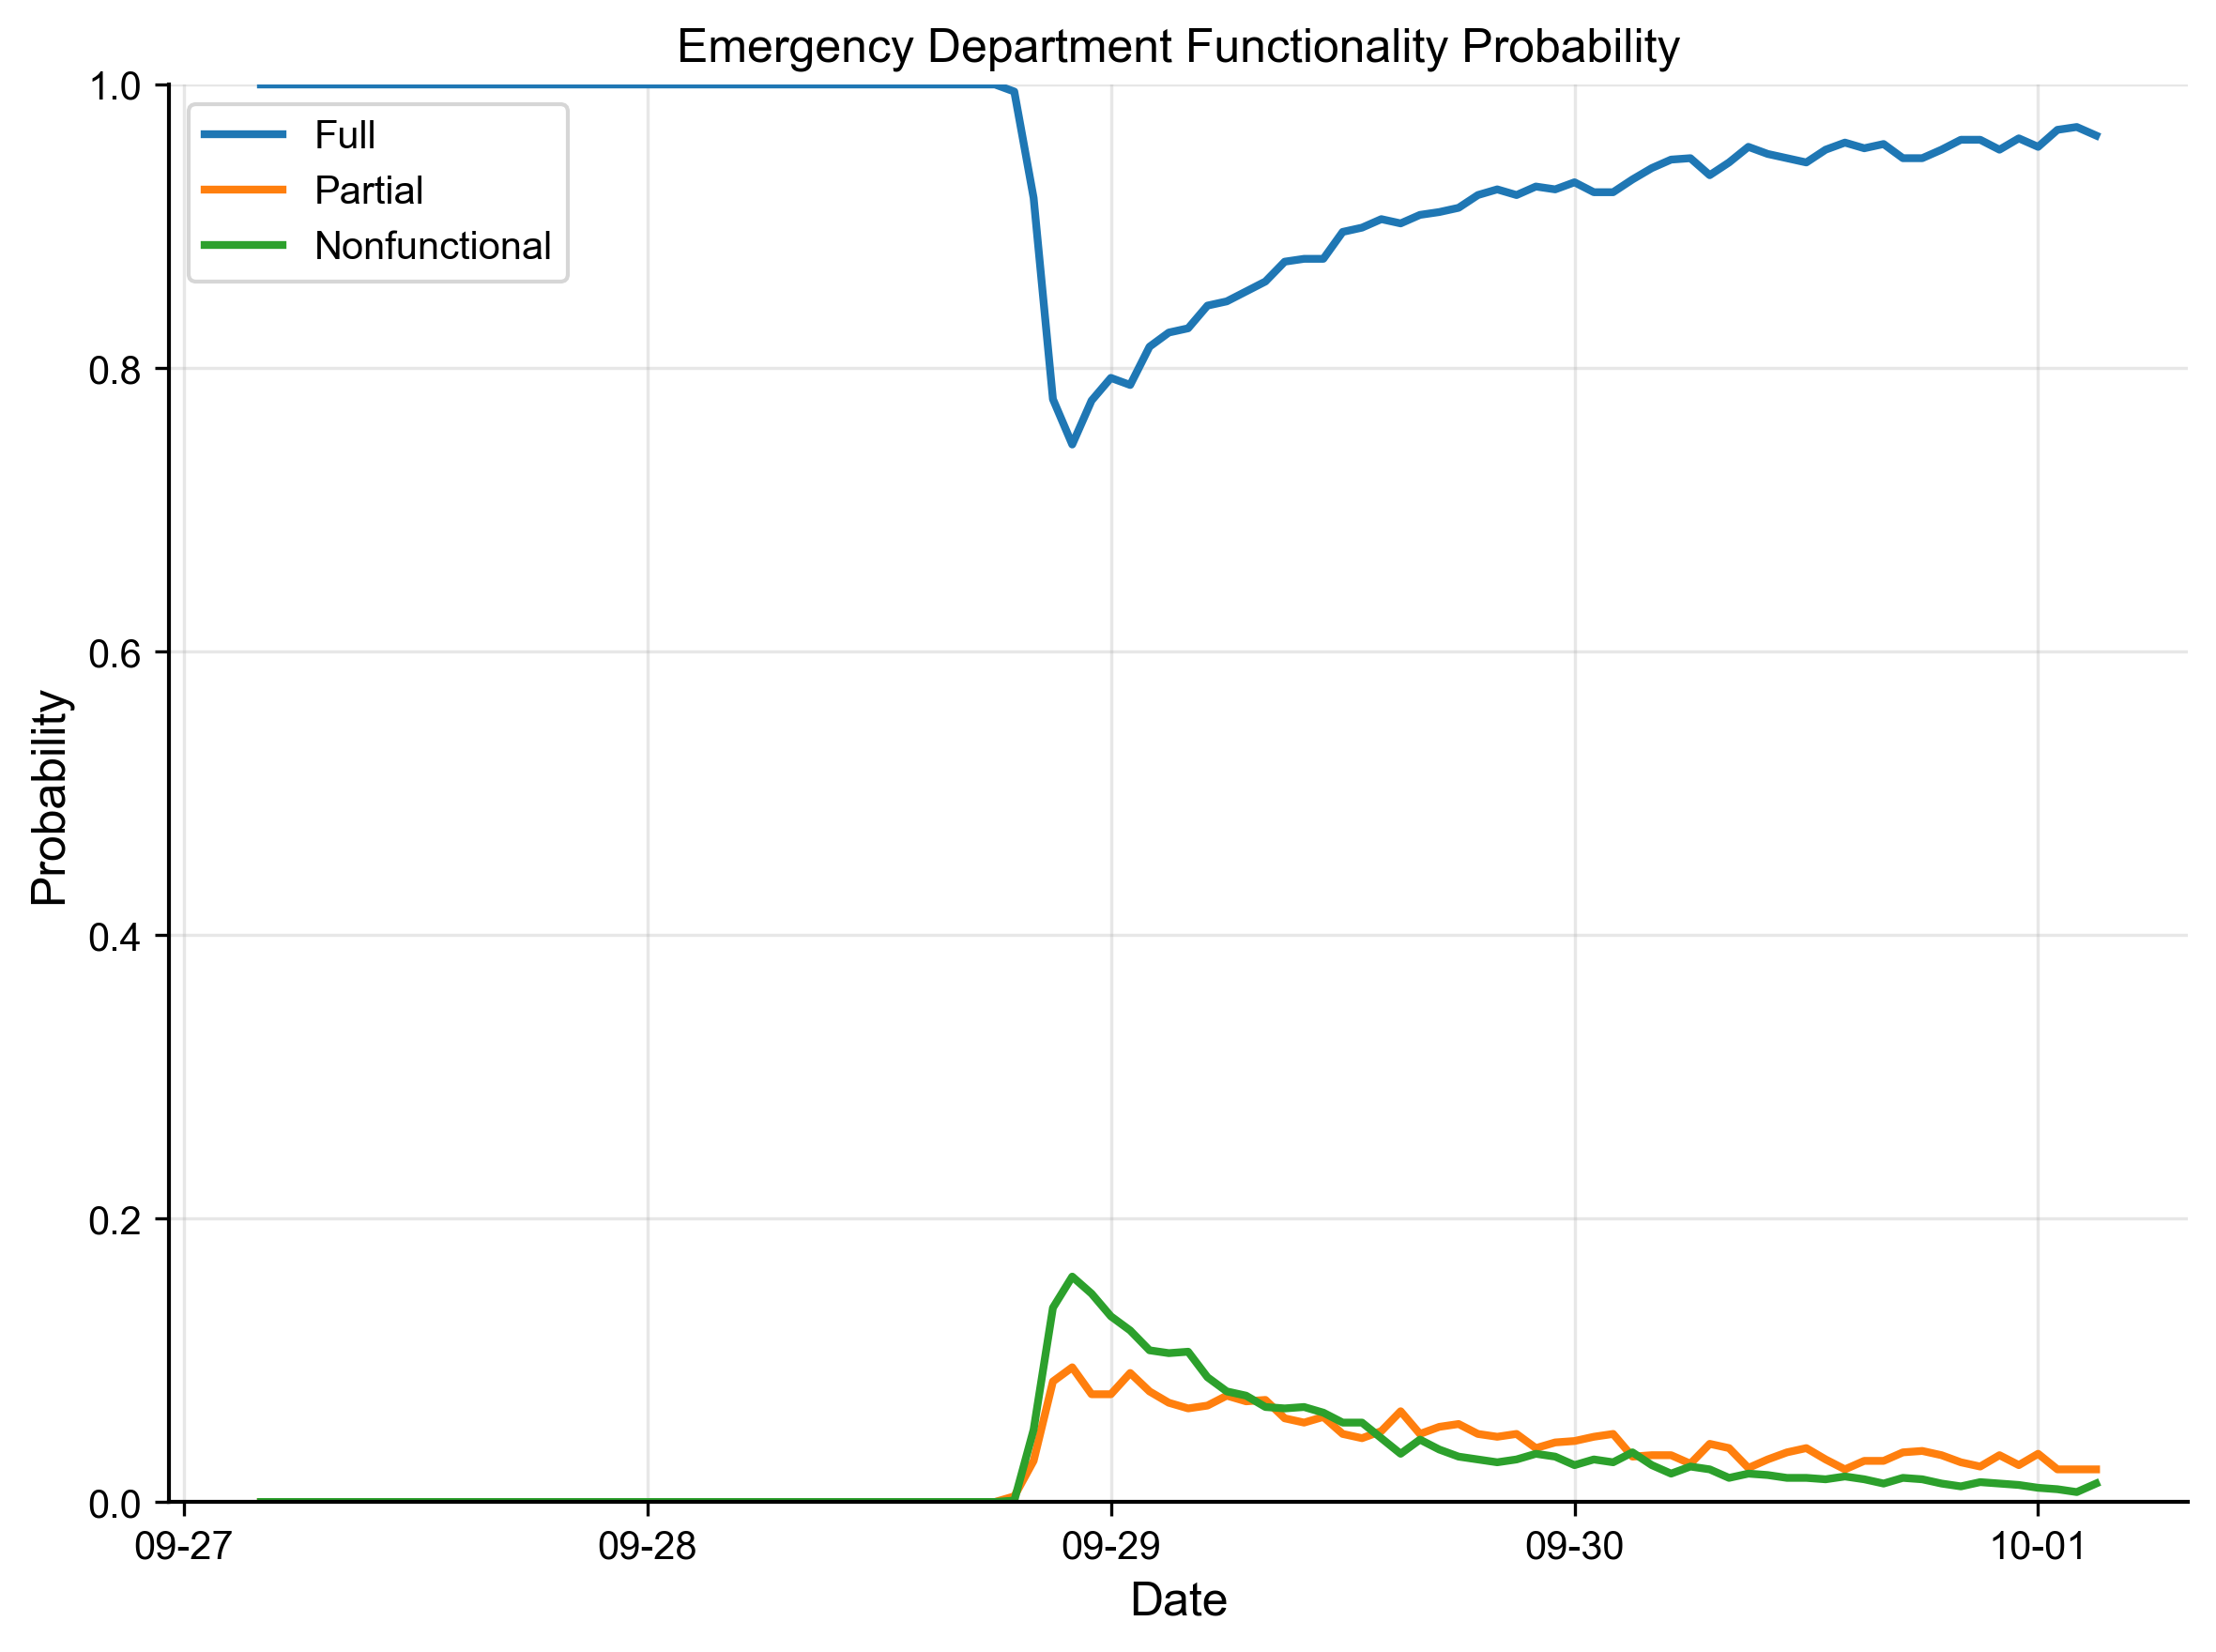

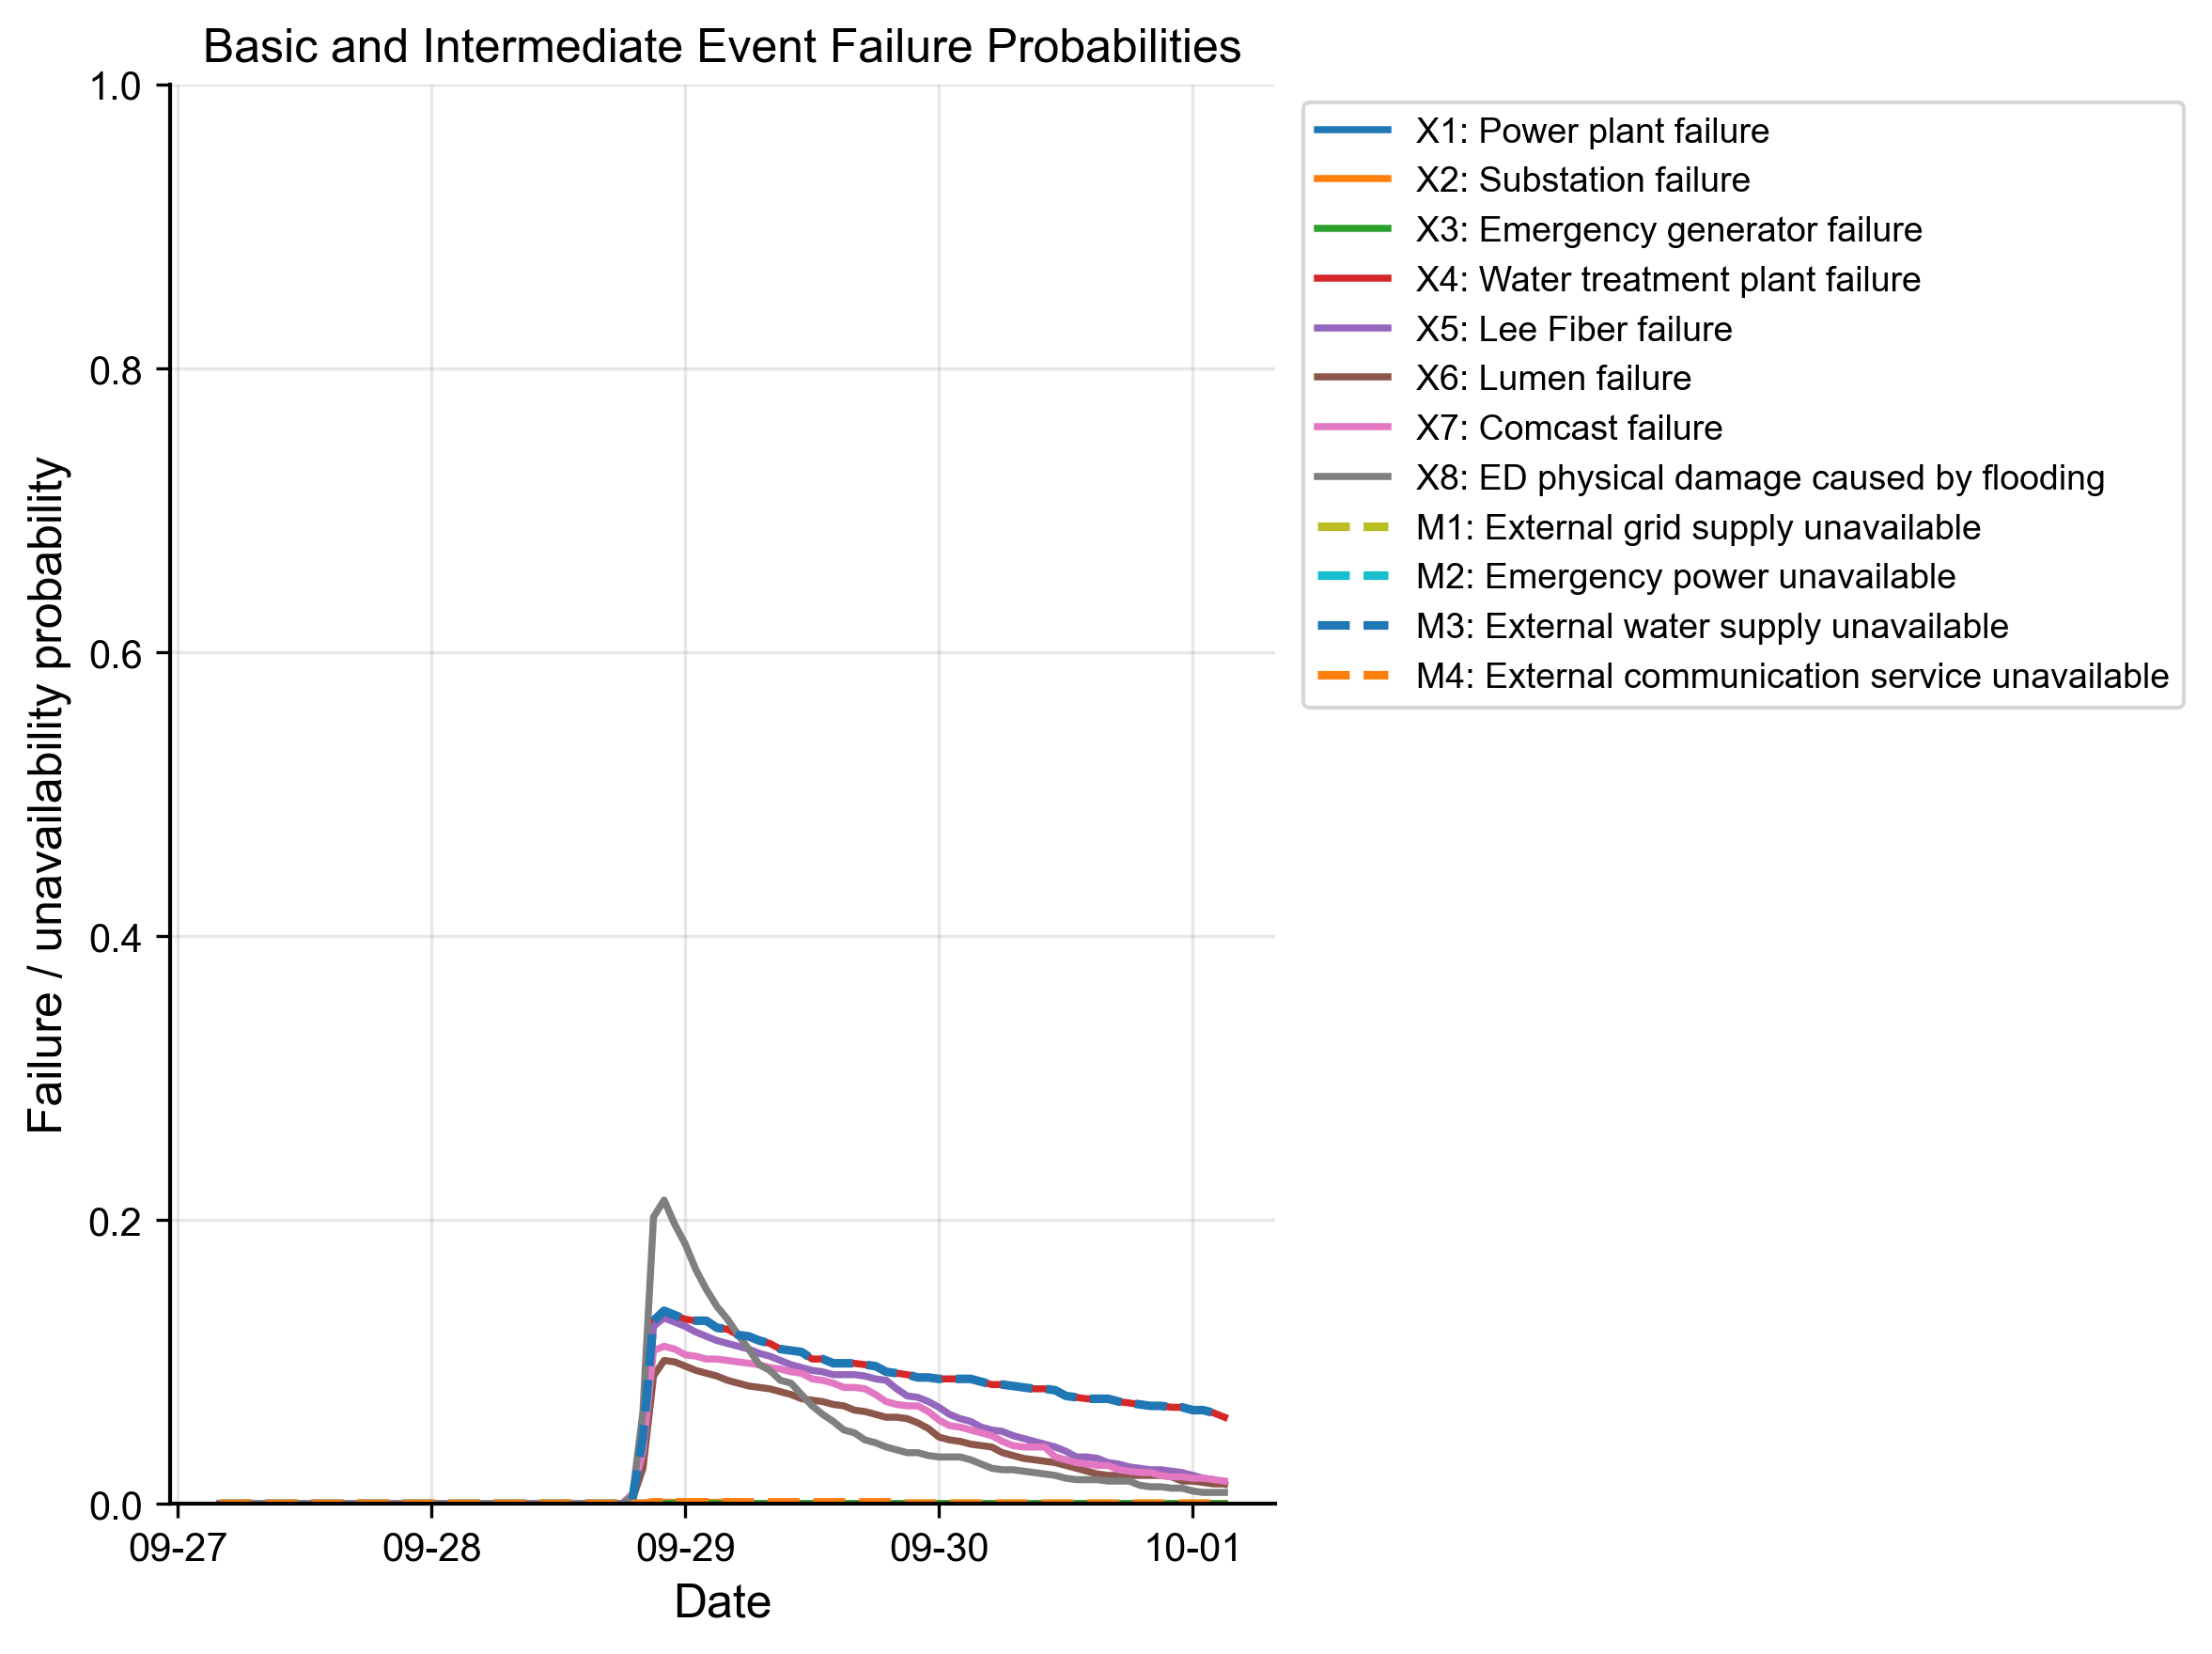

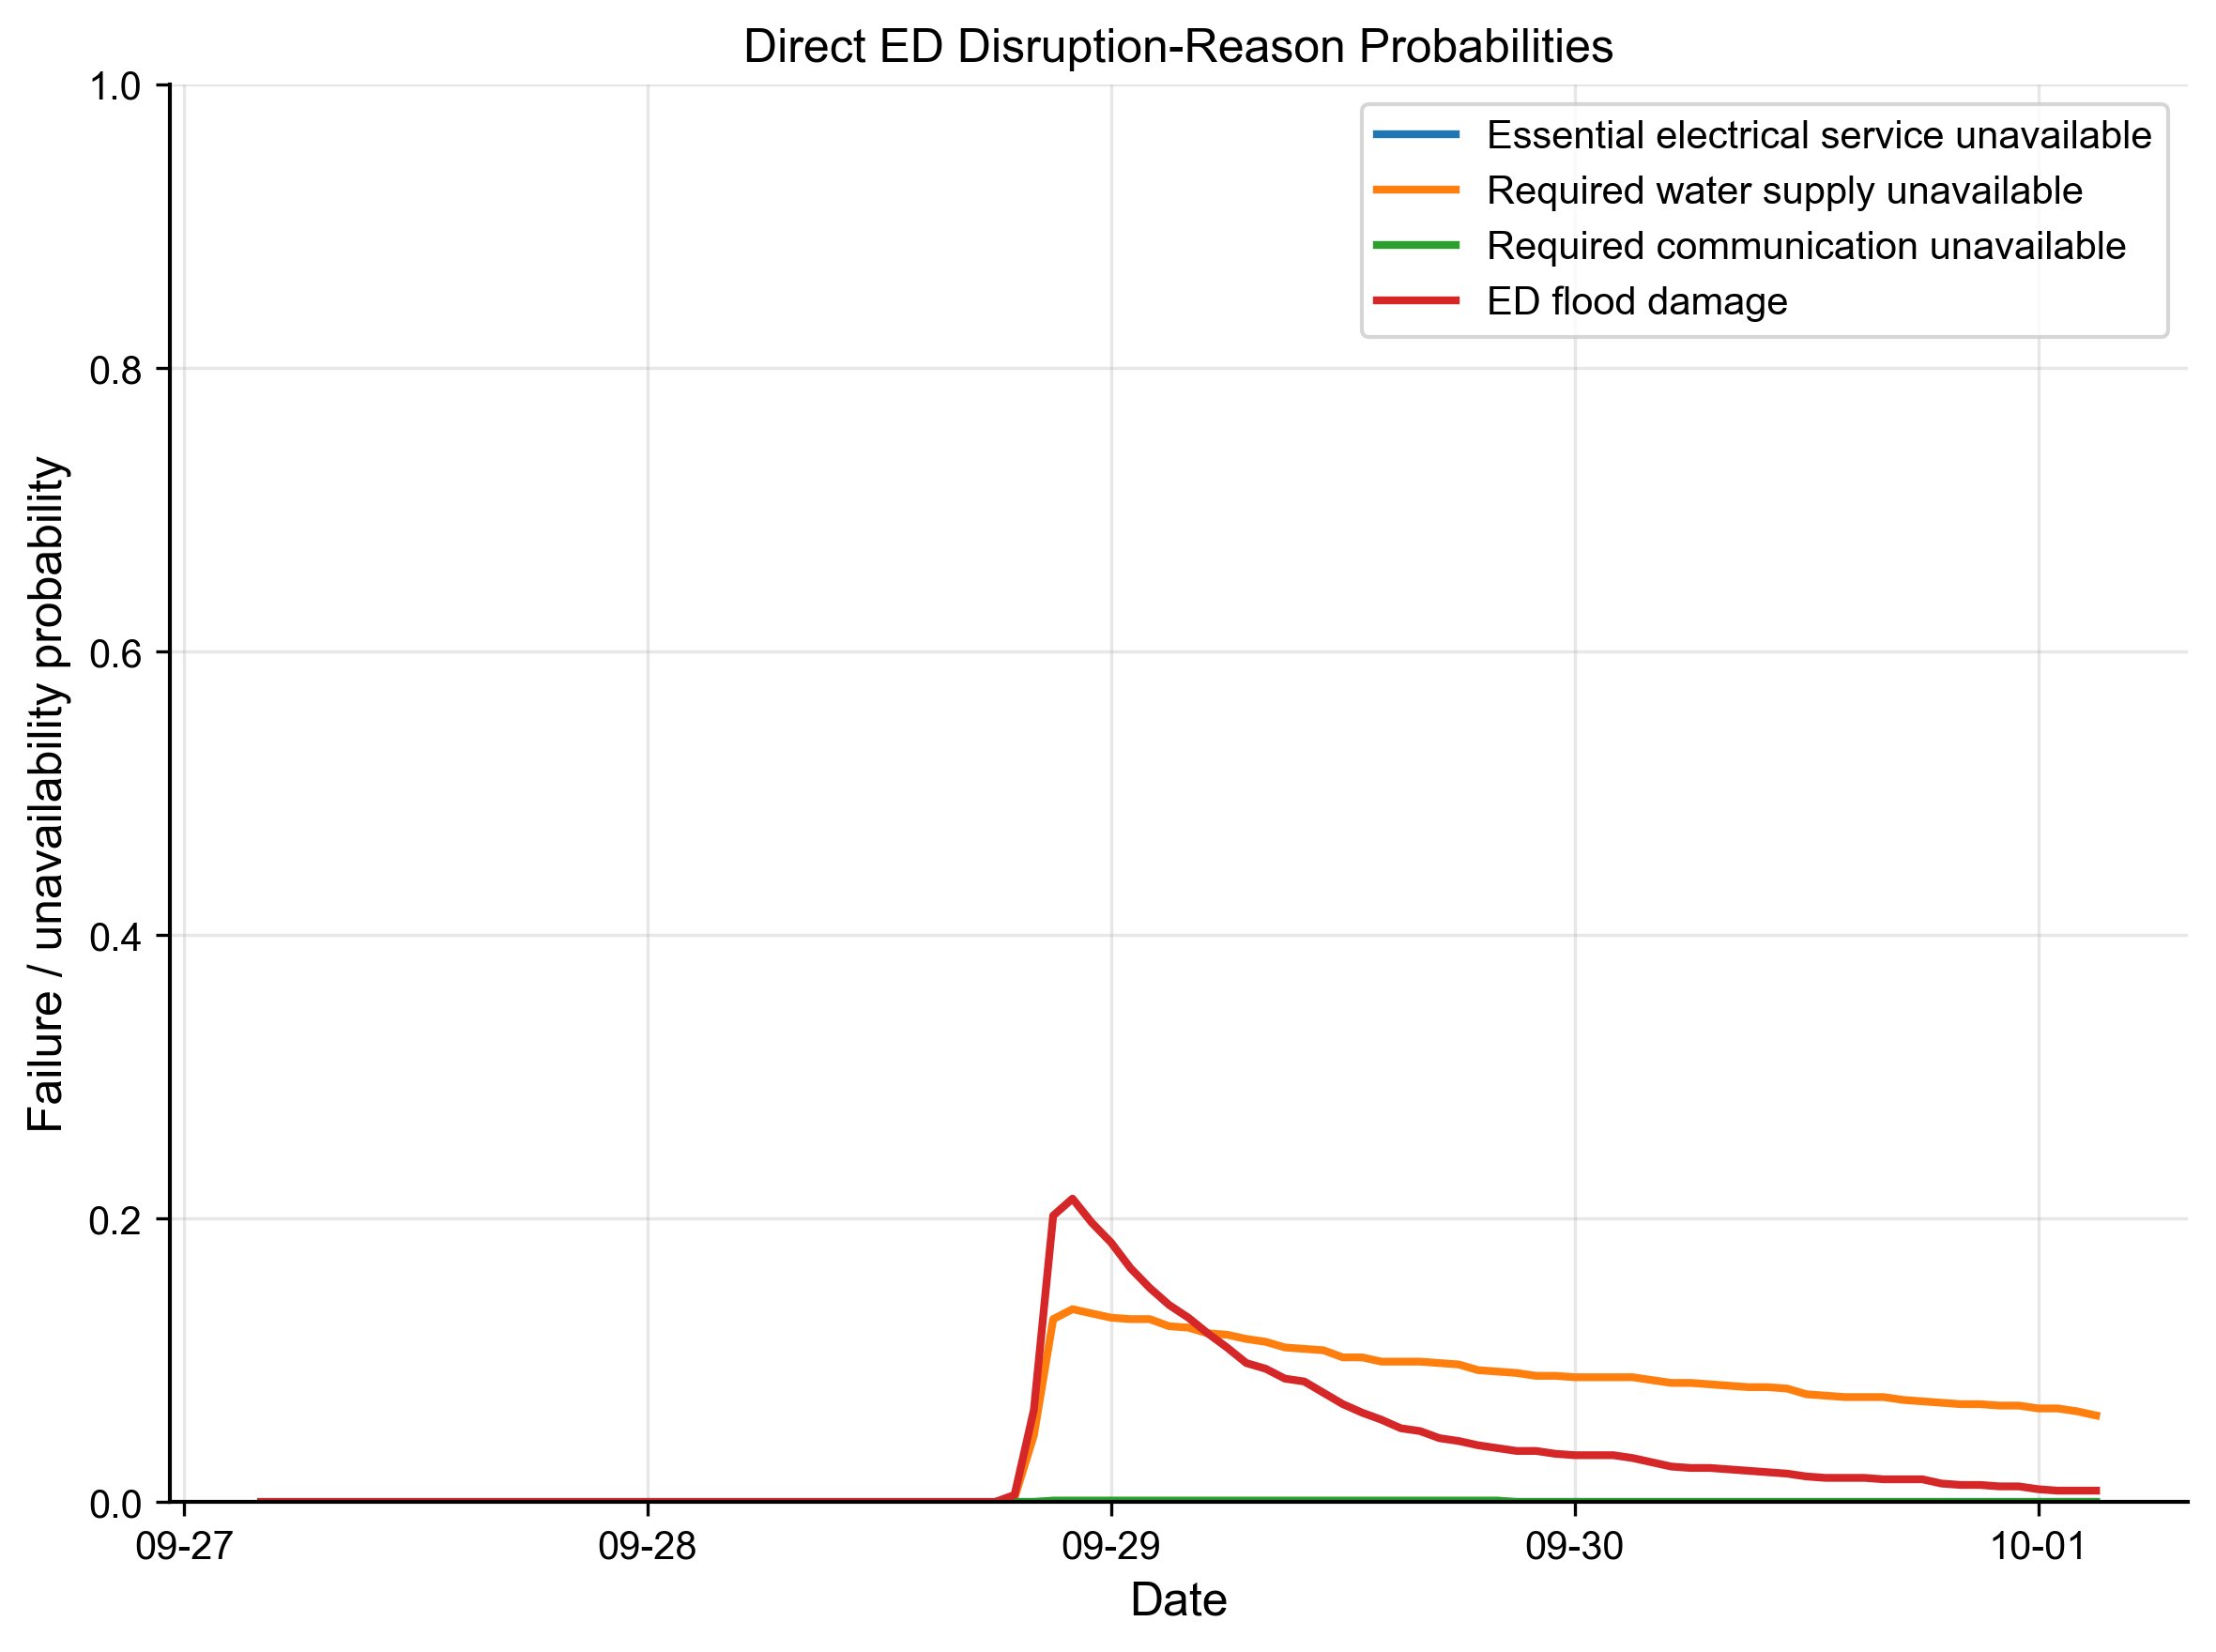

In [78]:
USGS_FILE = r"../../Data/Ian/FL - USGS-02291673.xls"
df_flood_hourly = load_usgs_hourly(USGS_FILE)
hazard_series = build_hazard_series_same_for_all_nodes(df_flood_hourly)

state_samples, ed_samples = run_dbn_monte_carlo(
    hazard_series=hazard_series,
    ed_cpt=ed_cpt,
    n_samples=1000,
    seed=42,
    use_routine_failures=False,
    use_recovery=True,
    allow_missing_recovery_as_no_recovery=False,
)

node_probability_summary, ed_probability_summary = summarize_dbn(
    state_samples,
    ed_samples,
)

# Optional numerical inspection.
display(node_probability_summary.head())
display(ed_probability_summary.head())

# Figure 1: ED functionality probabilities, restricted to 2022-09-27 through 2022-10-01.
plot_ed_functionality_probabilities(
    ed_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
)

# Figure 2: all basic events (X1-X8) plus FT intermediate events (M1-M4).
plot_basic_and_intermediate_failure_probabilities(
    node_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
)

# Figure 3: the four direct reasons entering the ED functionality CPT.
plot_service_failure_reason_probabilities(
    node_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
)


In [81]:
pd.set_option("display.max_columns", 100)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

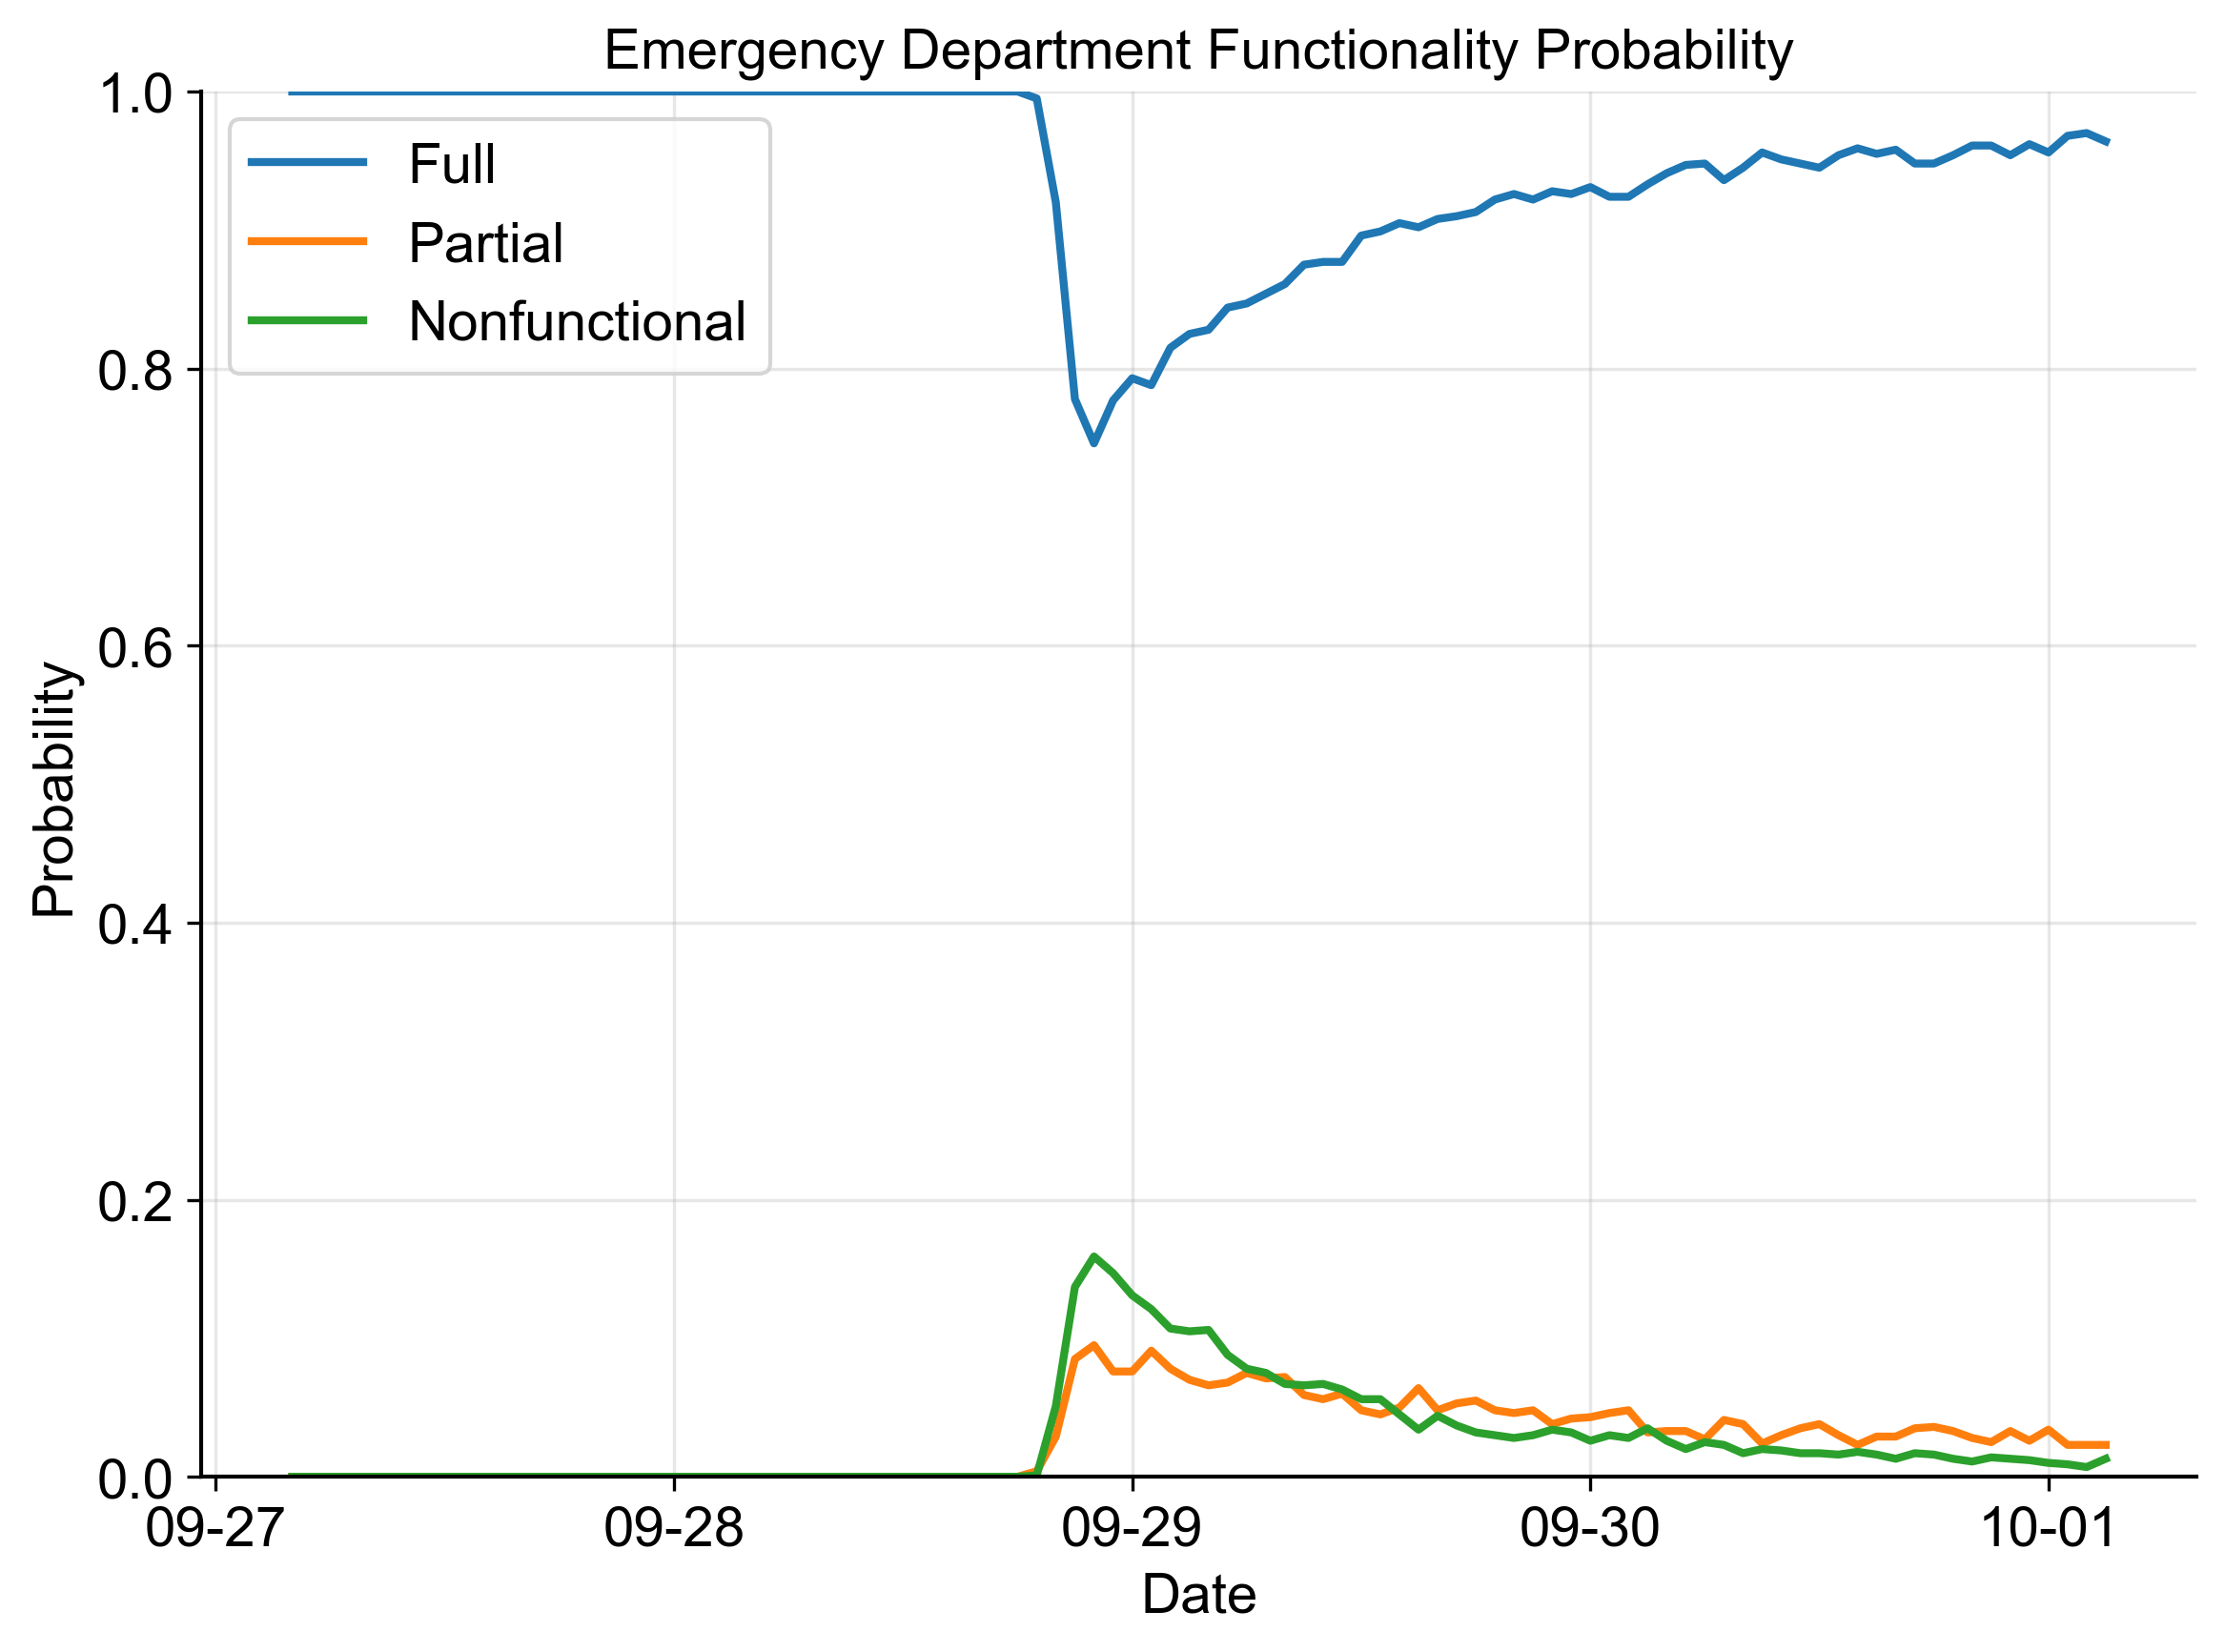

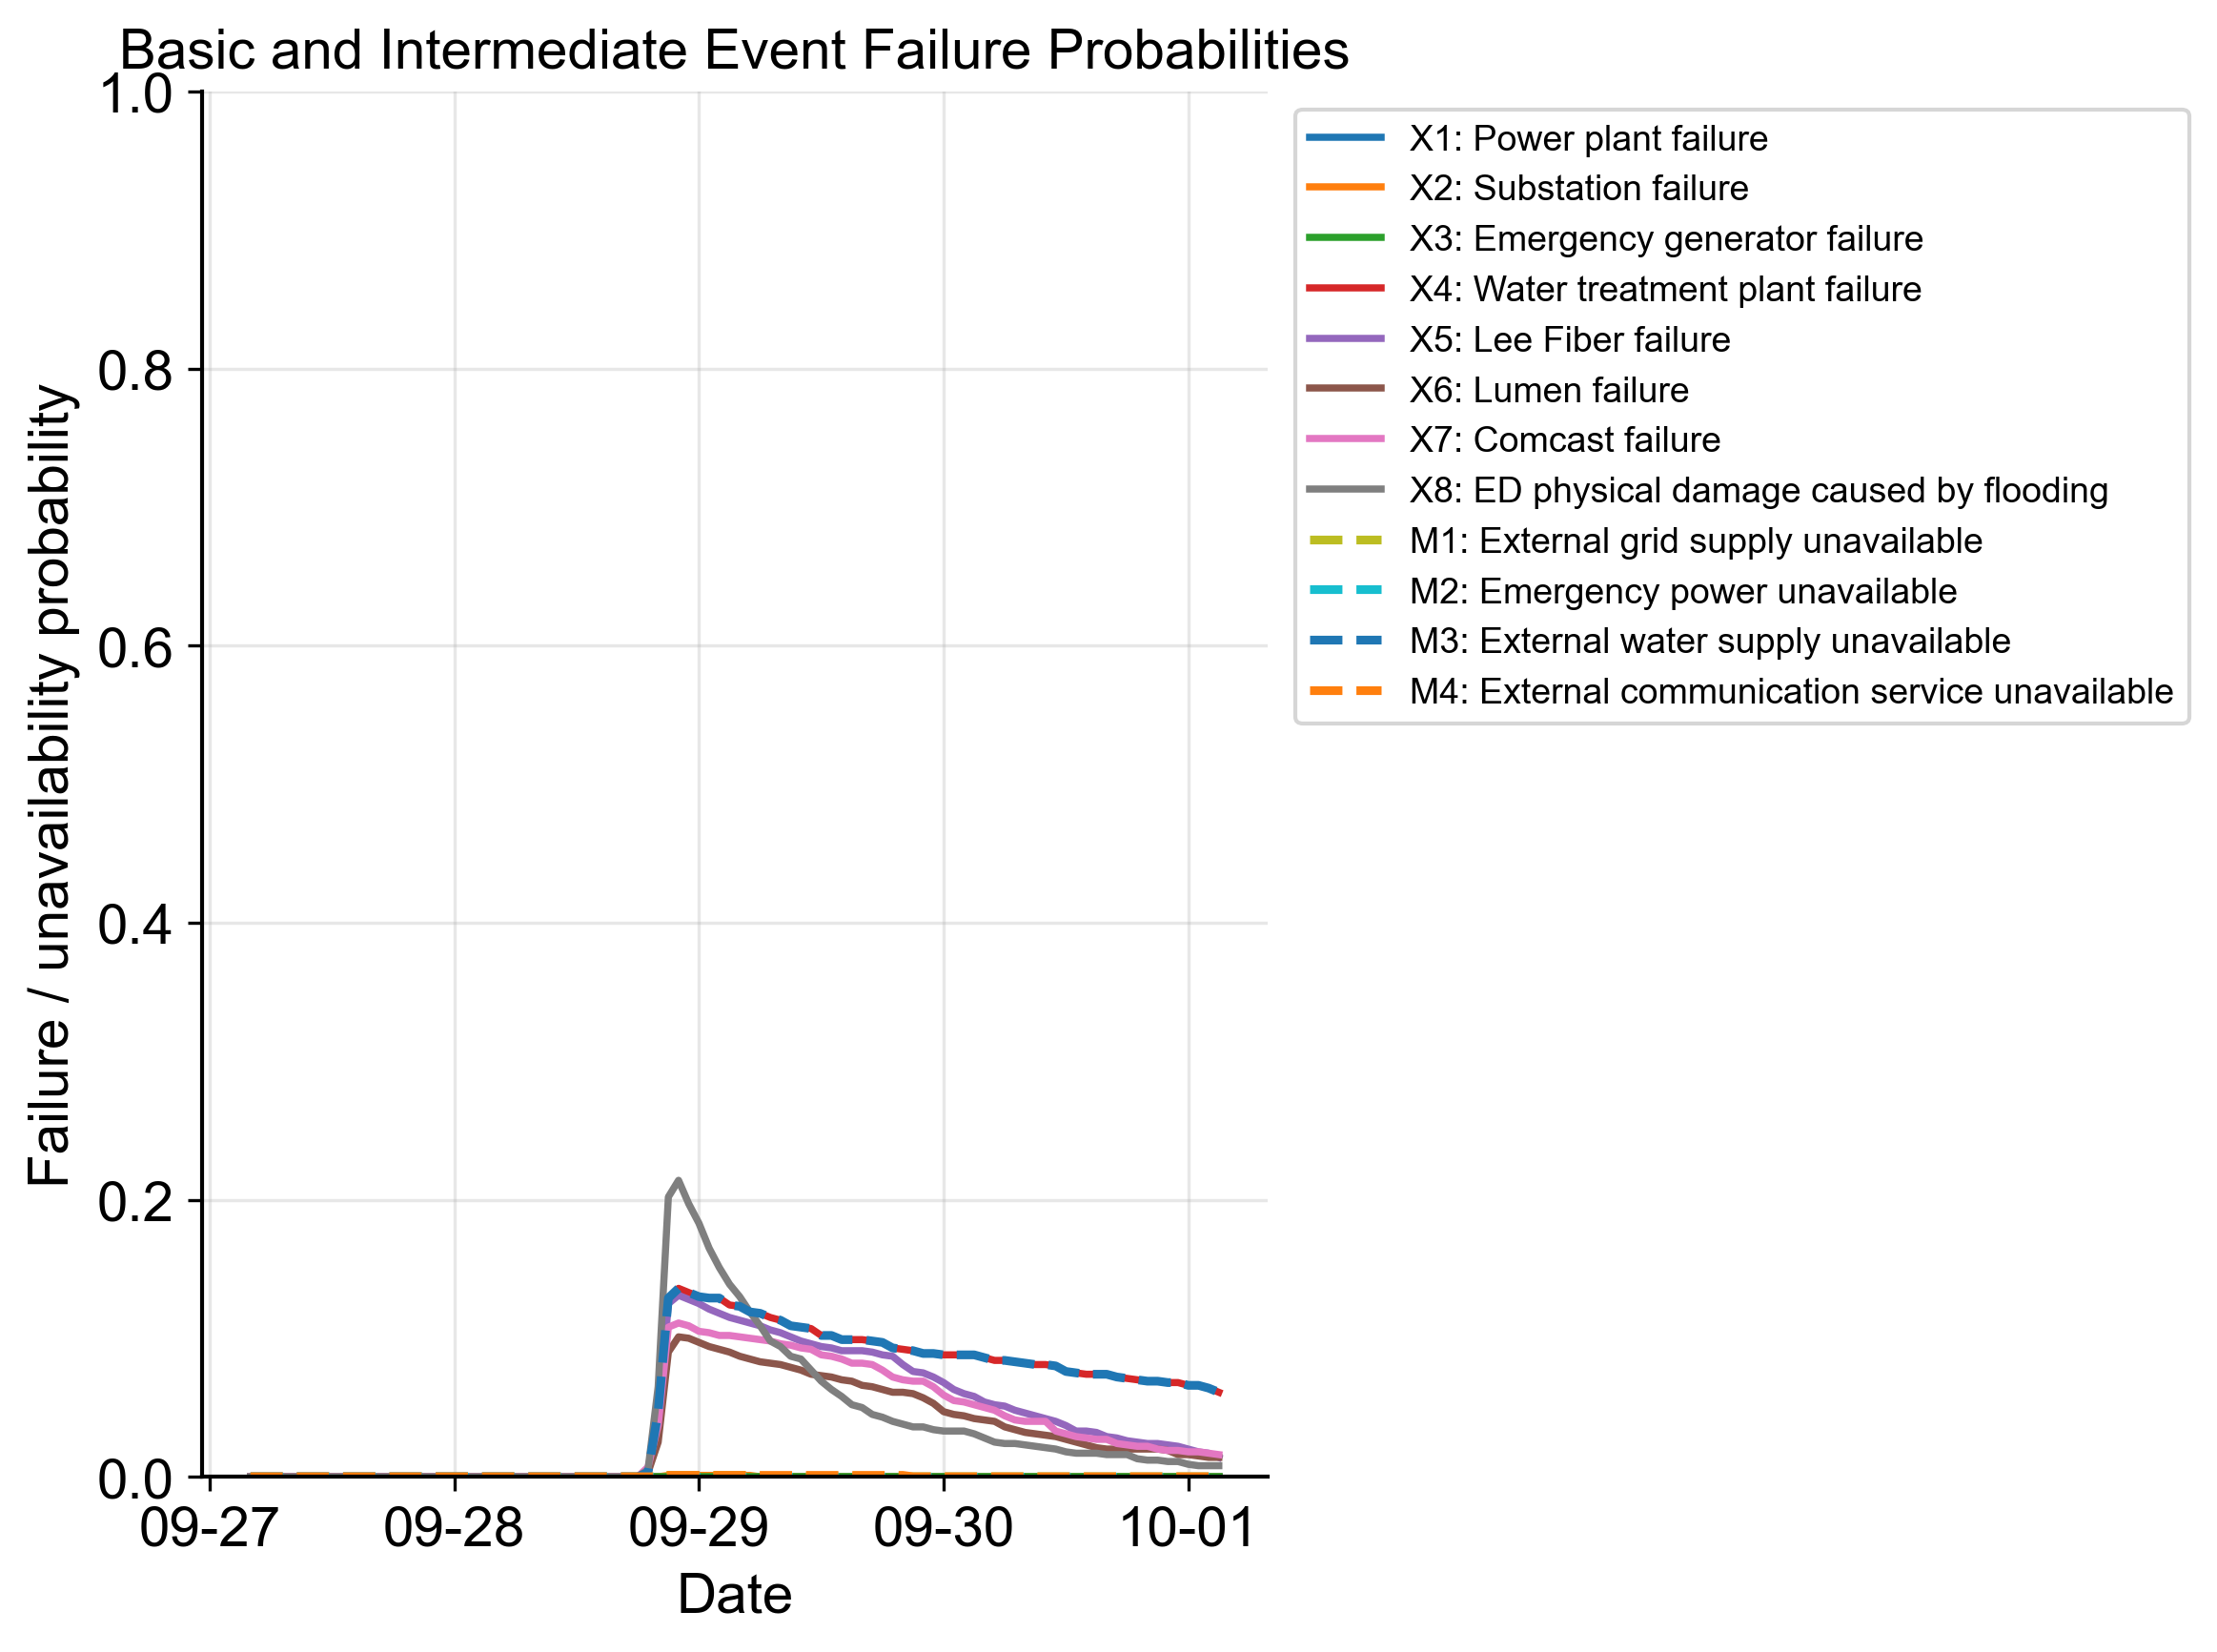

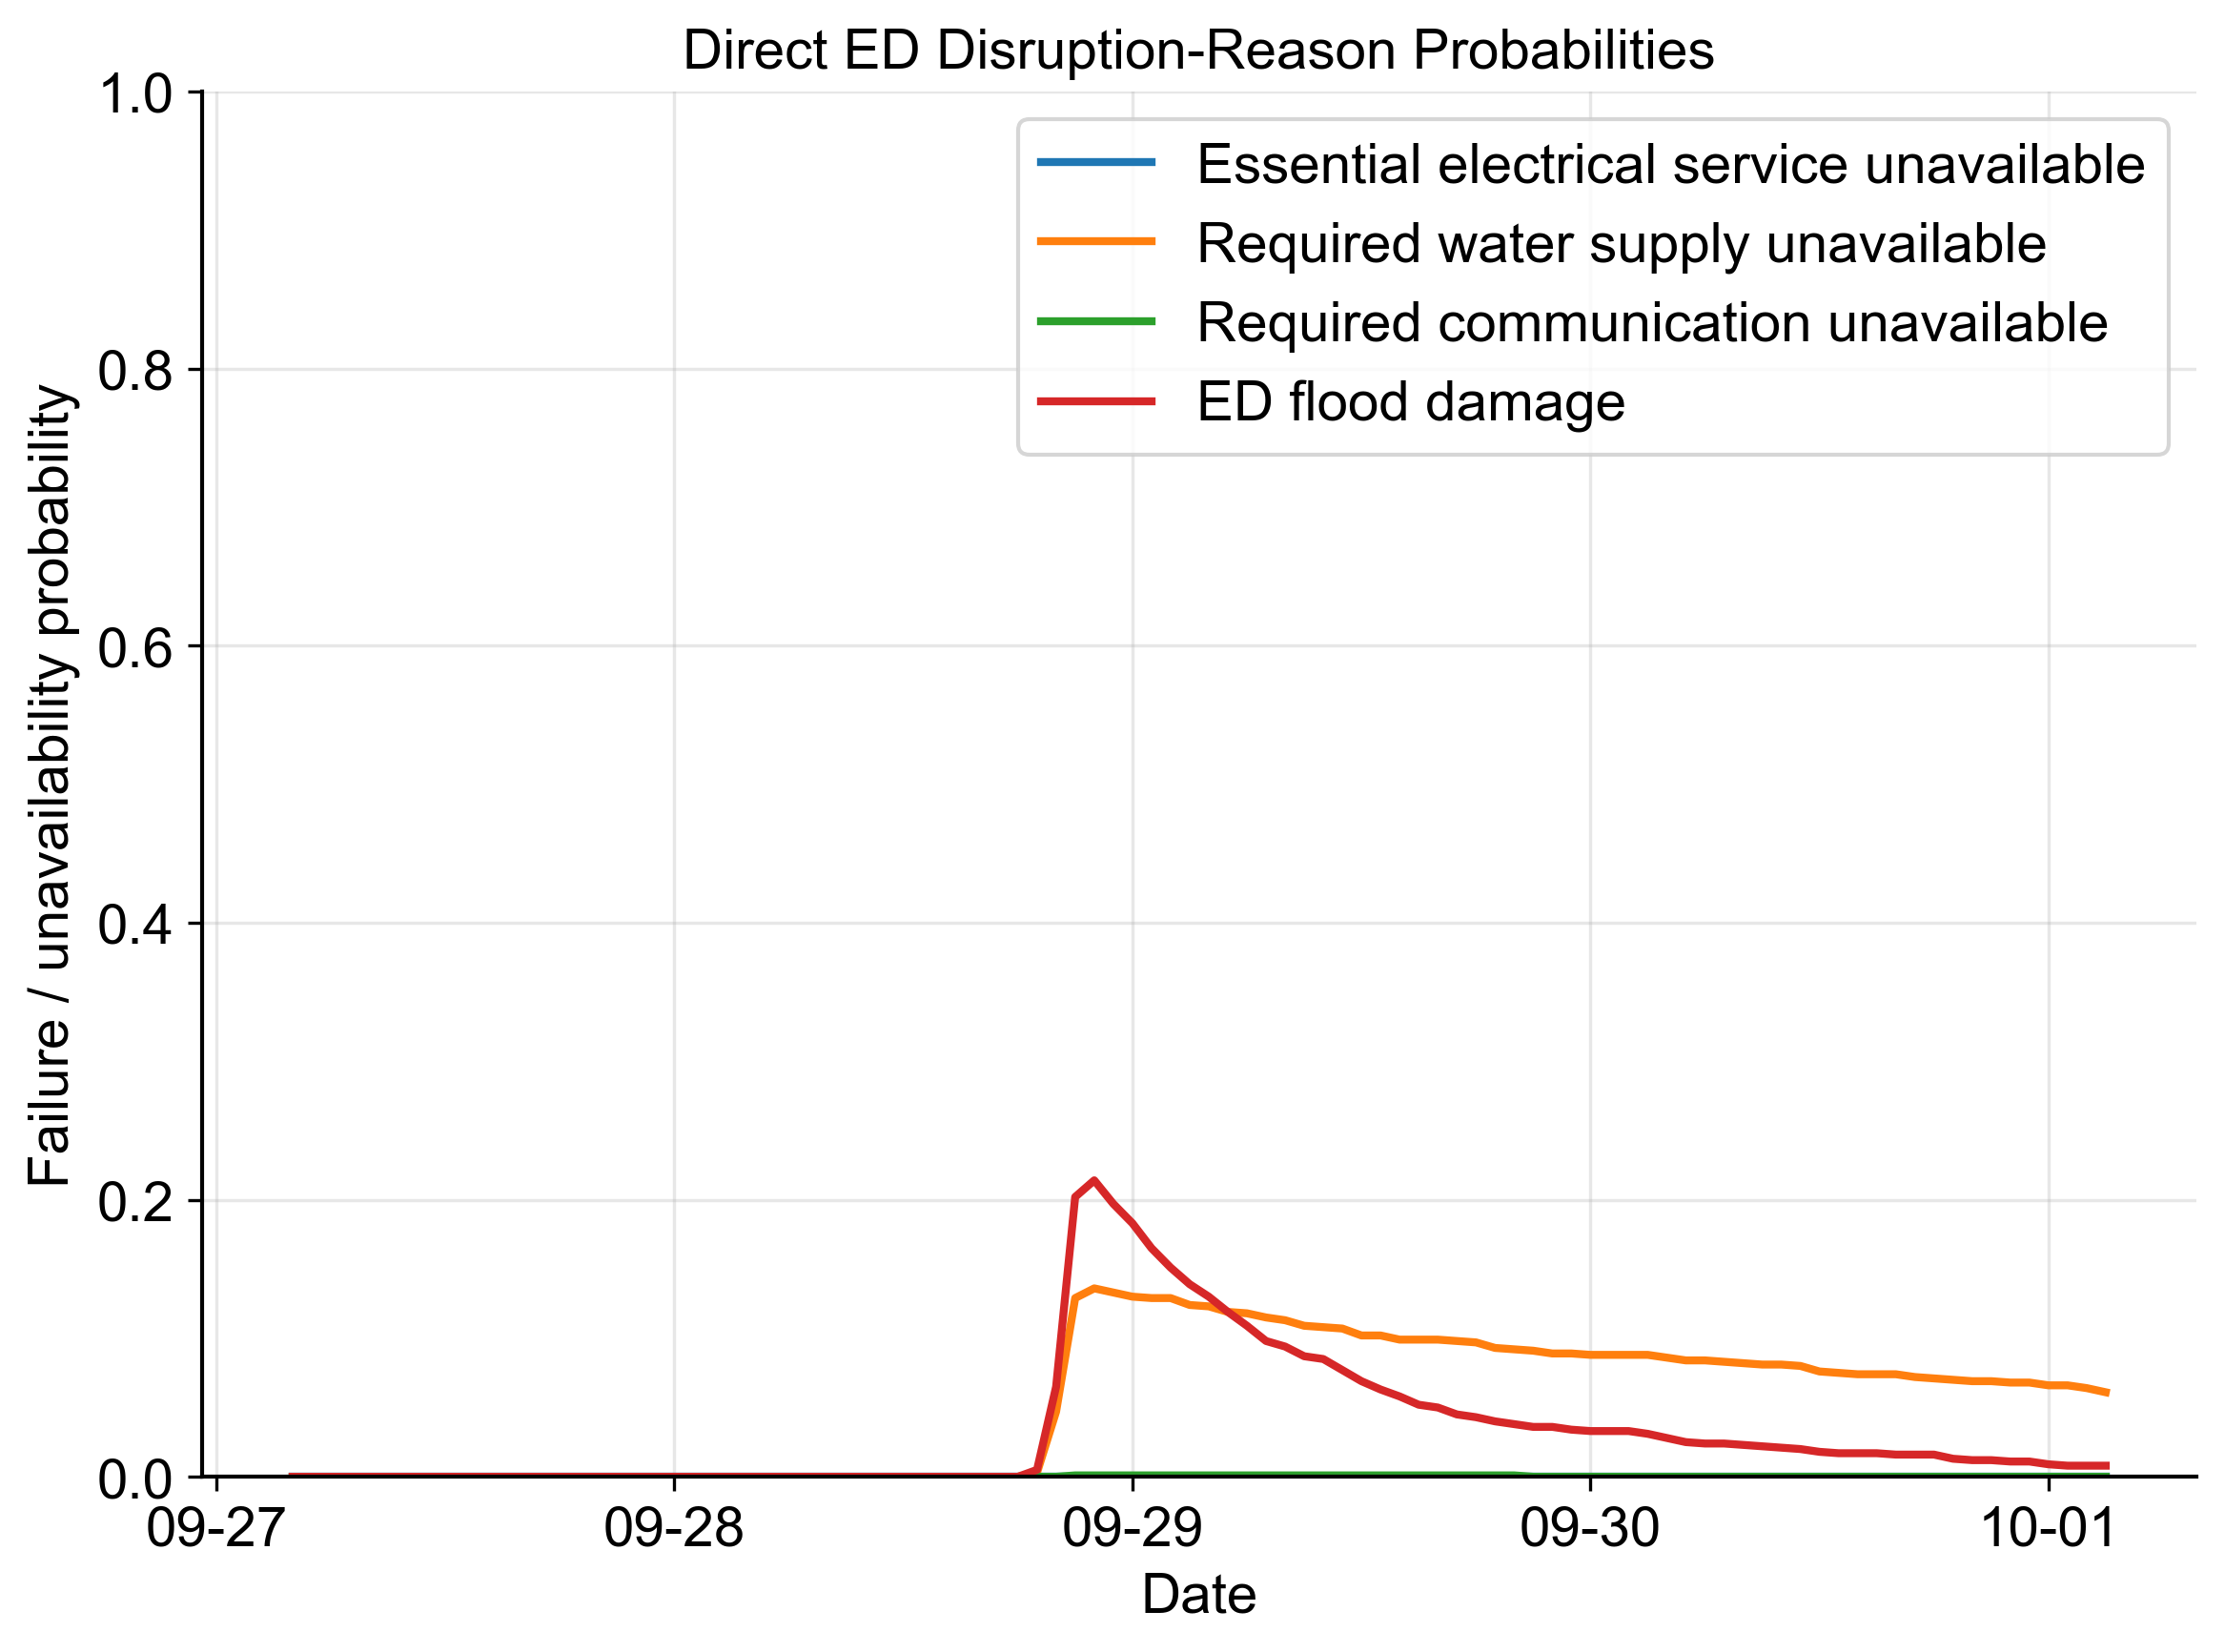

In [82]:
# Figure 1: ED functionality probabilities, restricted to 2022-09-27 through 2022-10-01.
plot_ed_functionality_probabilities(
    ed_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
)

# Figure 2: all basic events (X1-X8) plus FT intermediate events (M1-M4).
plot_basic_and_intermediate_failure_probabilities(
    node_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
)

# Figure 3: the four direct reasons entering the ED functionality CPT.
plot_service_failure_reason_probabilities(
    node_probability_summary,
    start_date=ANALYSIS_START_DATE,
    end_date=ANALYSIS_END_DATE,
)

### Reading the two failure-probability figures

- Figure 2 traces the detailed FT mechanisms. `X1`–`X8` are physical/basic events, while `M1`–`M4` are deterministic intermediate events calculated from those states.
- Figure 3 isolates the four direct parents of `ED_functionality`: `E`, `W`, `C`, and `X8`. These probabilities are **not forced to sum to 1**, because multiple disruption reasons can occur simultaneously in the same Monte Carlo realization.
- `X8` appears in both figures intentionally: it is a basic event and also a direct ED disruption reason.


## 14. Optional: export/import the ED CPT

This makes expert-elicitation or spreadsheet editing easier while keeping the simulation code unchanged.

In [21]:
def export_ed_cpt_template(path="ed_functionality_cpt_template.csv"):
    ed_cpt.to_csv(path, index=False)
    return Path(path).resolve()


def load_ed_cpt(path):
    cpt = pd.read_csv(path)
    validate_ed_cpt(cpt)
    return cpt

# Example:
# export_ed_cpt_template()
# ed_cpt = load_ed_cpt("ed_functionality_cpt_completed.csv")

## 15. Notes on what changed from the previous HealthPark notebook

1. Five substations were replaced by one simplified `X2` substation.
2. Generator activation and the 6.3-day runtime clock were removed; `X3` is simply emergency-generator failure/unavailability.
3. Multiple Comcast nodes were replaced by one `X7` Comcast node.
4. T-Mobile, transportation, operations capability, and Tier 1/2/3 hospital nodes were removed from this ED-focused model.
5. Water, electrical, and communication relationships now follow the validated deterministic FT gates rather than noisy-OR strengths.
6. The ED endpoint is one three-state Bayesian node rather than three binary tier nodes.
7. Physical ED flood damage is separated from ED functionality as `X8`.
8. Fragility probabilities are converted to incremental DBN transition probabilities instead of being independently resampled at every hour.
9. Only `X1`–`X8` carry temporal persistence/recovery; FT aggregation nodes are recalculated within each time slice.
10. The ED CPT is left entirely to expert/data parameterization.